# Comparación de modelos

El siguiente documento presenta los entrenamientos de varios modelos usando datos agregados del experimento 1st_test. este sirve como punto de partida y comparación para arquitecturas más complejas.

Los modelos empleados son: 
- Convolutional Neural Network (CNN)
- Long Short-Term Memory (LSTM)
- Recurrent Neural Network (RNN)
- Deep Neural Network (DNN)


 
En este notebook emplea conjunto de datos tabulados generados meediante el notebook `TF_Generador_Datasets.ipynb` (disponible en este repositorio). Para el entramiento de todos los modelos se emplea el conjunto de datos tabulares crado a partir del experimento 1st_test del [IMS-Rexnord Bearing](https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/). Este conjunto se compone de 17.248 filas y 24 columnas. El experimento 1st_test, es el primero de 3 experimentos que conforman el dataset IMS-Rexnord Bearing realizado en la universidad de Cincinnati cuyos investigadores dispusieron datos sobre vibraciones en elementos rodantes. Las columnas corresponden a diferentes parámetros y estadísticos obtenidos de los datos crudos, algunos de estos parámetros son: amplitud máxima, amplitud promedio, error cuadrático medio, varianza, desviación estándar, entre otros.



El conjunto de datos compuesto de 24 columnas y 17.248 filas se agrupó cada 8 filas correspondientes a cada sensor del experimento 1st_test,  para crear un tensor de la forma (2156 filas , 8 sensores, 24 columnas). Este proceso de agrupación permite que los modelos entiendan la relacion entre los canales de los experimentos, sin embargo esto provoca que se pierdan algunas etiquetas asignadas a cada canal, siendo orginalmente 7, sólo se utilizan 4.

**MODIFICACIONES**

* Reducción de dimensionalidad: Se disminuyó la cantidad de variables del dataset mediante el análisis de importancia de características utilizando el método SHAP.
* Evaluación de métricas: Se implementó una comparación estructural de las métricas de optimización (`Precision`, `Recall` y `F1-score`).
* Se vinculó la configuración de Weights & Biases para registrar parámetros y comparar resultados en la web. 
* **Panel de Control en WandB:** [Tabla de Resultados — Clasificador de Vibraciones](https://wandb.ai/maanmuri-marck/TF_CEIA_Clasificador_Vibraciones/table?nw=nwusermaanmuri)



**Próximos Pasos (Robustez del Modelo)**
Para mejorar la tolerancia del modelo ante cambios o pérdidas en la cantidad de sensores (canales), se realizarán pruebas de entrenamiento con:
* Dropout de canales (ocultando sensores de forma aleatoria).
* Agregación de datos (recalculando los bloques estadísticos).


# Declaración de librerías


In [1]:
# LIBRERIAS
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten
from tensorflow.keras.models import Sequential

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from sklearn.metrics import precision_recall_fscore_support
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint
import wandb


2026-05-16 23:10:26.615897: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-16 23:10:26.616029: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-16 23:10:26.652938: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-16 23:10:26.724283: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-16 23:10:27.857439: W tensorflow/compiler/tf2

In [2]:
import keras_tuner as kt
# métrica F1 macro compatible con multiclase
class F1MacroScore(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.true_positives  = self.add_weight(name='tp', shape=(num_classes,), initializer='zeros')
        self.false_positives = self.add_weight(name='fp', shape=(num_classes,), initializer='zeros')
        self.false_negatives = self.add_weight(name='fn', shape=(num_classes,), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_classes = tf.argmax(y_pred, axis=1)
        y_true_flat    = tf.cast(tf.reshape(y_true, [-1]), tf.int64)

        # one-hot encoding vectorizado — sin loops
        y_true_oh = tf.one_hot(y_true_flat,    self.num_classes)  # (batch, num_classes)
        y_pred_oh = tf.one_hot(y_pred_classes, self.num_classes)  # (batch, num_classes)

        self.true_positives.assign_add(
            tf.reduce_sum(y_true_oh * y_pred_oh, axis=0)
        )
        self.false_positives.assign_add(
            tf.reduce_sum((1 - y_true_oh) * y_pred_oh, axis=0)
        )
        self.false_negatives.assign_add(
            tf.reduce_sum(y_true_oh * (1 - y_pred_oh), axis=0)
        )

    def result(self):
        precision    = self.true_positives / (self.true_positives + self.false_positives + 1e-7)
        recall       = self.true_positives / (self.true_positives + self.false_negatives + 1e-7)
        f1_per_class = 2 * precision * recall / (precision + recall + 1e-7)
        return tf.reduce_mean(f1_per_class)

    def reset_state(self):
        for var in self.variables:
            var.assign(tf.zeros_like(var))

In [3]:
# Carpeta de artefactos, modelos y resultados
dir_artifacts = "artefactos/artefactos_train_v7"

# crear carpeta si no existe
import os
os.makedirs(dir_artifacts, exist_ok=True)

umbral_shap = 0


In [4]:

def mostrar_grafica_agrupada(df, metrica, columna_salud, columna_canal, colores_salud, guardar_figura=False, nombre_figura="grafica_agrupada.png"   ):
    """
    Genera subplots verticales, uno para cada canal, mostrando la evolución de una métrica
    utilizando los nombres de archivo/timestamps en el eje X.
    """
    # Identificar los canales únicos y ordenarlos
    canales = sorted(df[columna_canal].unique())
    num_canales = len(canales)
    
    # Crear la figura con subplots compartiendo el eje X
    fig, axs = plt.subplots(num_canales, 1, figsize=(13, 3 * num_canales), sharex=True)
    
    # Si solo hay un canal, axs no es una lista, lo convertimos para poder usar índices
    if num_canales == 1:
        axs = [axs]

    # Variable para almacenar el df_canal del último canal y usarlo para los ticks
    df_ultimo_canal = None

    for i, canal in enumerate(canales):
        # Filtrar datos para el canal actual
        df_canal = df[df[columna_canal] == canal].reset_index(drop=True)
        df_ultimo_canal = df_canal # Guardamos referencia para los labels finales
        ax = axs[i]
        
        salud_labels_añadidos = set()

        # Dibujar segmentos por color según el estado de salud
        for j in range(len(df_canal) - 1):
            estado = df_canal.iloc[j][columna_salud]
            color = colores_salud.get(estado, 'gray')
            
            label = estado if estado not in salud_labels_añadidos else "_nolegend_"
            salud_labels_añadidos.add(estado)
            
            # Graficar segmento
            ax.plot([j, j+1], 
                    [df_canal.iloc[j][metrica], df_canal.iloc[j+1][metrica]], 
                    color=color, 
                    label=label,
                    linewidth=1.5)

        # Configuración de cada subplot
        ax.set_title(f'Análisis de {metrica} - {canal}', fontweight='bold', fontsize=10)
        ax.set_ylabel(metrica, fontsize=9)
        ax.grid(True, linestyle='--', alpha=0.5)

    # --- Configuración de los Timestamps en el último eje ---
    # Usamos axs[-1] (la lista de ejes) en lugar de ax
    if df_ultimo_canal is not None:
        tick_step = max(1, len(df_ultimo_canal) // 12) # Ajustado a 12 etiquetas para legibilidad
        tick_idx = list(range(0, len(df_ultimo_canal), tick_step))
        
        # Aseguramos que el último índice esté incluido
        if (len(df_ultimo_canal) - 1) not in tick_idx:
            tick_idx.append(len(df_ultimo_canal) - 1)
            
        tick_labels = [df_ultimo_canal.loc[idx, 'archivo'] for idx in tick_idx]

        axs[-1].set_xticks(tick_idx)
        axs[-1].set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
        axs[-1].set_xlabel("Timestamp / Archivo", fontsize=10)

    # Crear una leyenda única para toda la figura
    handles, labels = axs[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    fig.legend(by_label.values(), by_label.keys(), loc='center left', 
               bbox_to_anchor=(0.85, 0.95), title="Estado de Salud")

    plt.tight_layout(rect=[0, 0, 0.88, 1]) 
    
    # Guardar figura si se indicó
    if guardar_figura:
        fig.savefig(nombre_figura, dpi=300, bbox_inches='tight')
        print(f"Figura guardada como: {nombre_figura}")
    
    plt.show()

# --- Ejemplo de cómo llamar a la función ---
COLORES_ETIQUETA = {
    "Normal":                  "#2ecc71",
    "Early":                   "#3498db",
    "Suspect":                 "#f1c40f",
    "Inner race failure":      "#e67e22",
    "Rolling element failure": "#e74c3c",
    "Stage 2 failure":         "#9b59b6",
    "Inminent failure":        "#c0392b",
}


# Limpieza y armado de tensores

## Carga de datasets


In [5]:
df = pd.read_csv("../datos/datos_generados/estadisticos_agregados/dataset_agregado_1st_test_con_salud.csv")

# cargar los datasets de estadisticos agregados
# df_agregado_1st_test = pd.read_csv('datos/datos_generados/estadisticos_agregados/dataset_agregado_1st_test_con_salud.csv')
df_agregado_2nd_test_path = "../datos/datos_generados/estadisticos_agregados/dataset_agregado_1st_test_con_salud.csv"
df_agregado_2nd_test_name = os.path.basename(df_agregado_2nd_test_path)
df_agregado_2nd_test = pd.read_csv(df_agregado_2nd_test_path)

df_agregado_3rd_test_path = "../datos/datos_generados/estadisticos_agregados/dataset_agregado_3rd_test_reetiquetado.csv"
df_agregado_3rd_test_name = os.path.basename(df_agregado_3rd_test_path)
df_agregado_3rd_test = pd.read_csv(df_agregado_3rd_test_path)

In [6]:
df.head()

,archivo,canal,peak_amplitude,mean_amplitude,rms_amplitude,peak_to_peak_amplitude,crest_factor,variance,standard_deviation,standard_error,...,skewness,kurtosis,hoc3,hoc4,entropy,mean_frequency,rms_frequency,envelope_rms,salud,salud_miltos
0,2003.10.22.12.06.24,Canal 1,0.5540,-0.094596,0.124617,1.108,4.445630,0.006581,0.081122,0.000567,...,-0.029898,1.069246,-0.000016,0.000046,1.178086,3011.599741,3669.348883,0.148695,saludable,Early
1,2003.10.22.12.06.24,Canal 2,0.6325,-0.093883,0.117496,1.265,5.383175,0.004991,0.070649,0.000494,...,0.220211,3.065961,0.000078,0.000076,0.936417,3965.247247,4995.648585,0.137100,NaN,Early
2,2003.10.22.12.06.24,Canal 3,0.5165,-0.093812,0.130452,1.033,3.959305,0.008217,0.090648,0.000633,...,-0.092175,0.209605,-0.000069,0.000014,1.338470,3002.578036,3950.131469,0.158855,NaN,Early
3,2003.10.22.12.06.24,Canal 4,0.3930,-0.093753,0.121644,0.786,3.230726,0.006008,0.077509,0.000542,...,-0.053114,0.292136,-0.000025,0.000011,1.435646,3355.919142,4567.916463,0.144240,NaN,Early
4,2003.10.22.12.06.24,Canal 5,0.4480,-0.090811,0.128888,0.896,3.475883,0.008365,0.091463,0.000639,...,0.034348,0.405279,0.000026,0.000028,1.476715,4377.833157,5106.402925,0.158043,NaN,Early


Figura guardada como: artefactos/artefactos_train_v7/grafica_agrupada_1st_test_variance.png


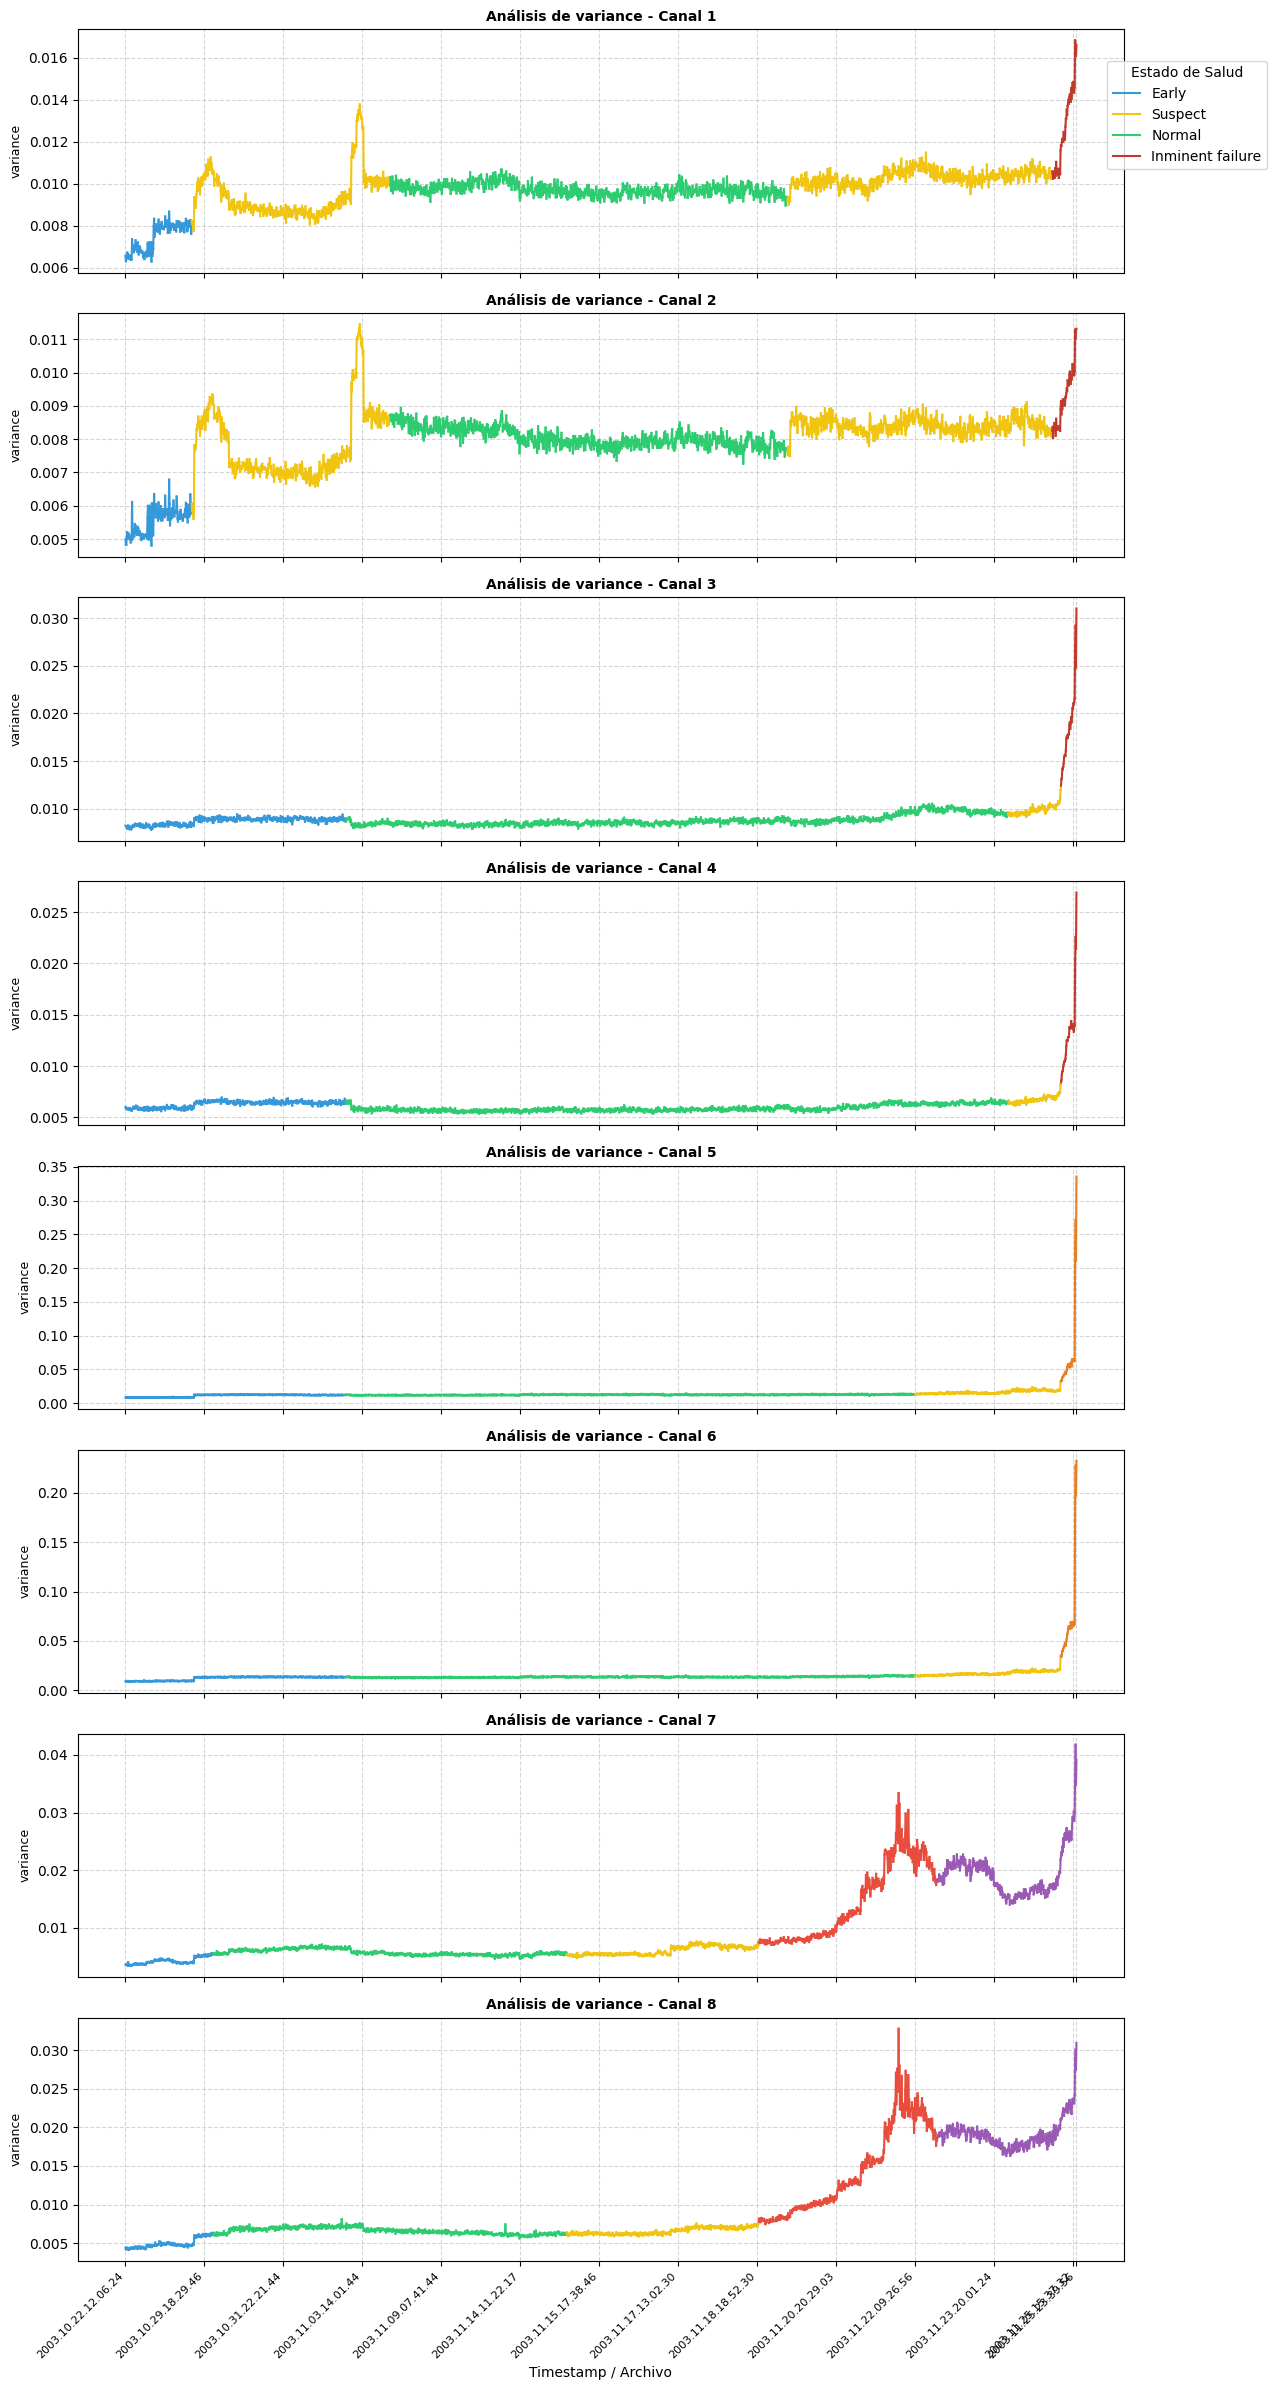

In [ ]:
mostrar_grafica_agrupada(
    df,
    metrica='variance',
    columna_salud='salud_miltos',
    columna_canal='canal',
    colores_salud=COLORES_ETIQUETA,
    guardar_figura=True,
    nombre_figura=os.path.join(dir_artifacts, "grafica_agrupada_1st_test_variance(train).png")
)

Figura guardada como: artefactos/artefactos_train_v7/grafica_agrupada_2nd_test_variance.png


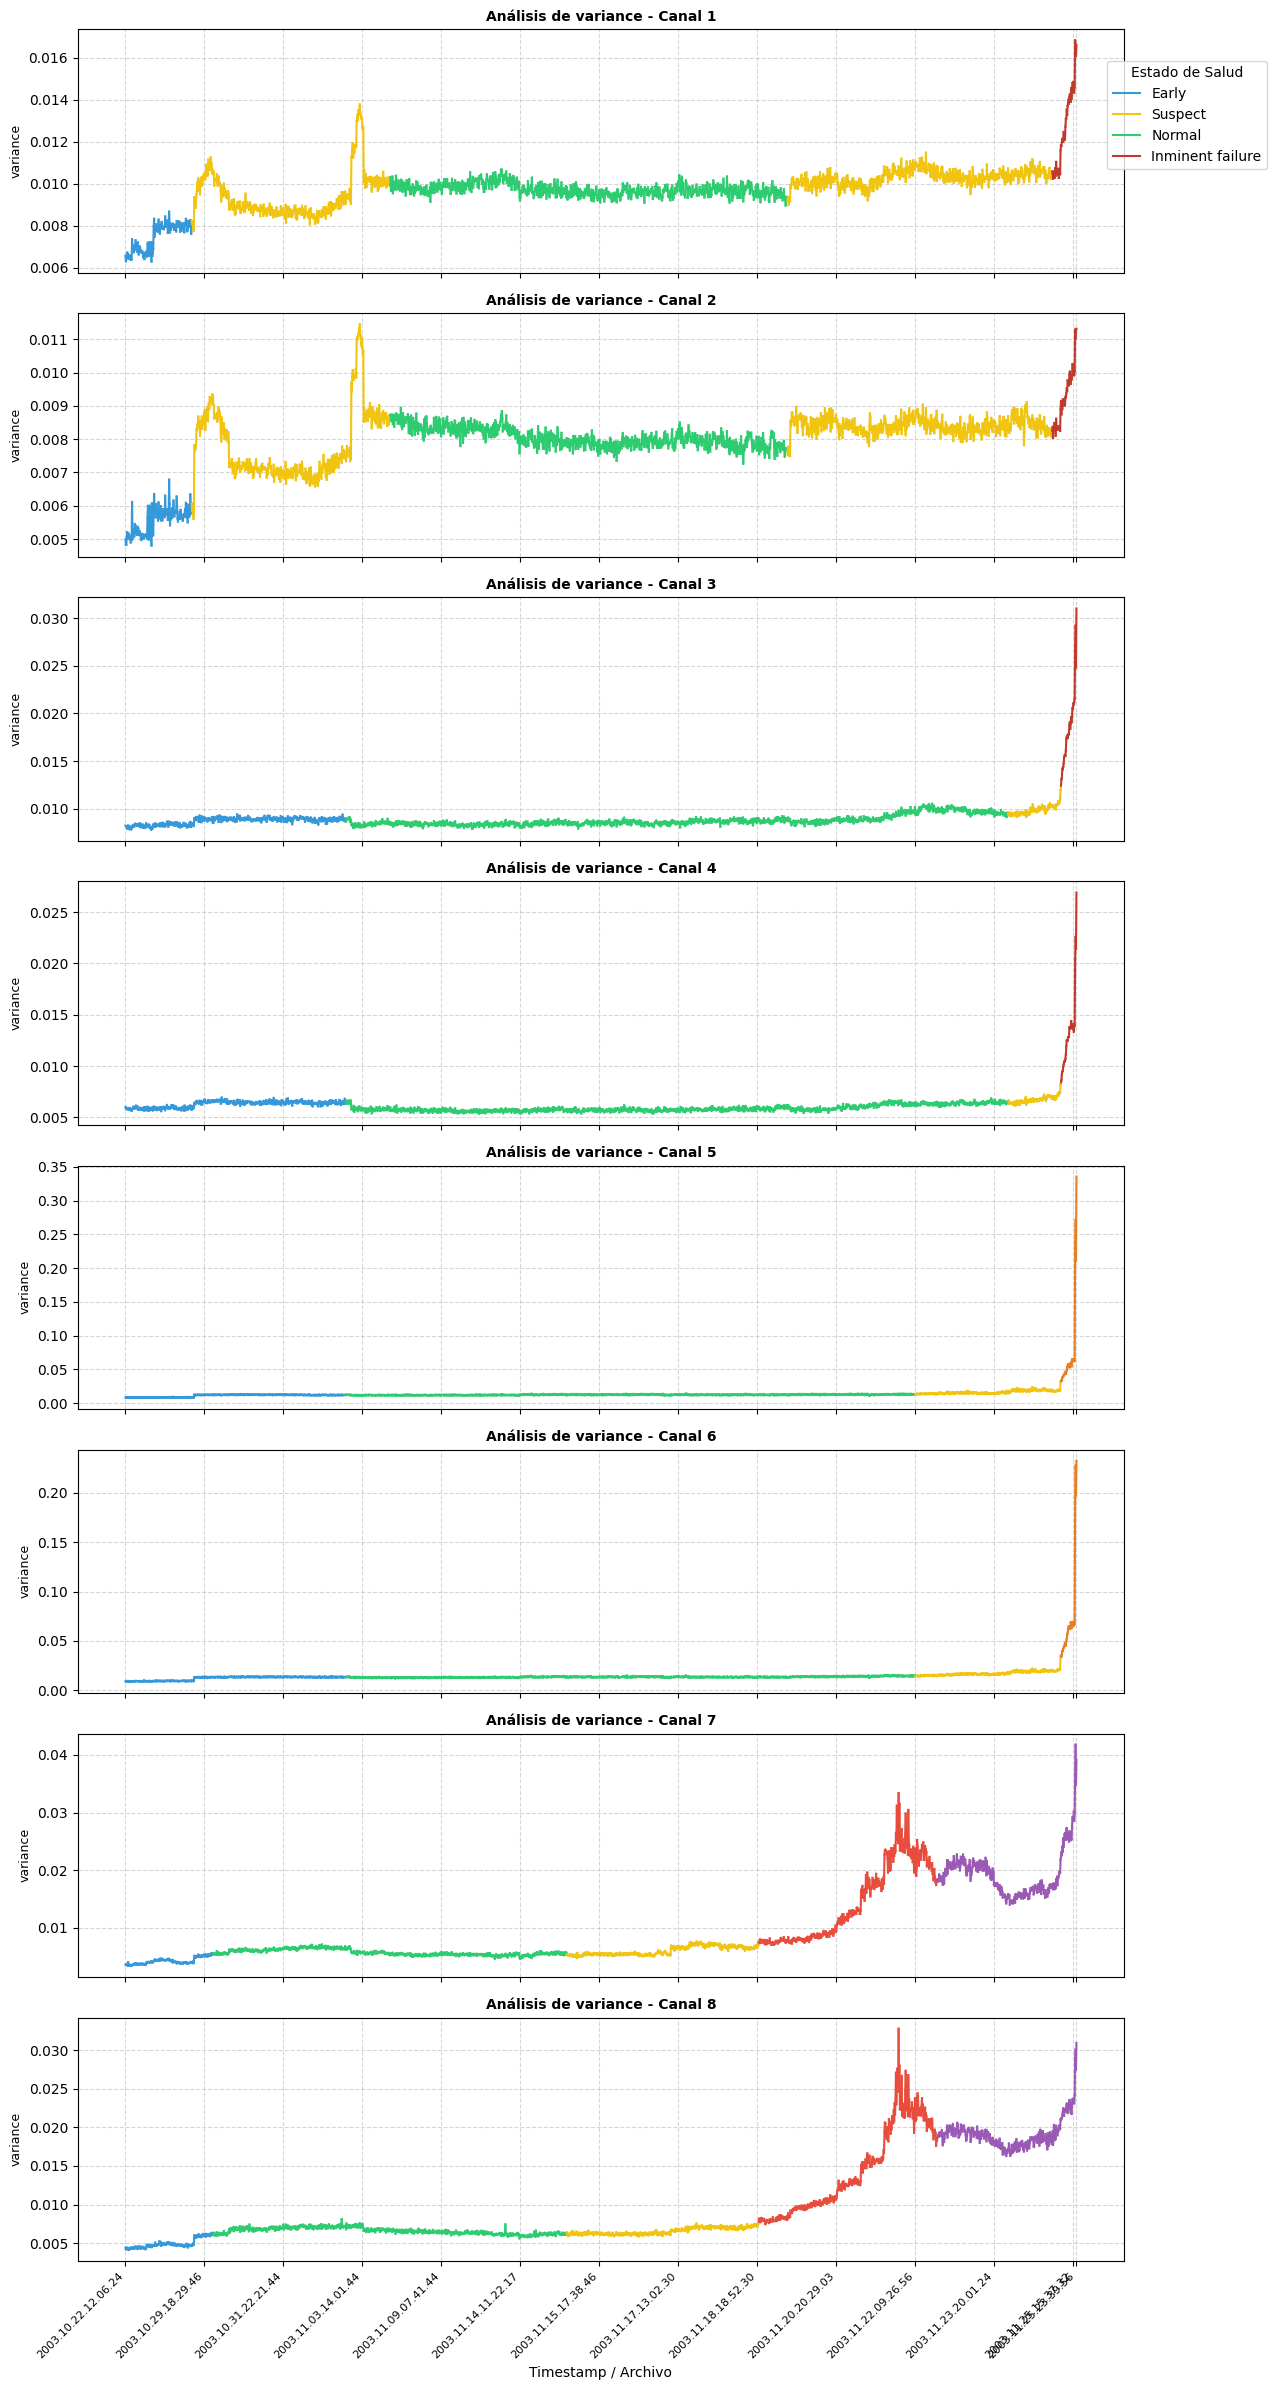

In [ ]:
mostrar_grafica_agrupada(
    df_agregado_2nd_test,
    metrica='variance',
    columna_salud='salud_miltos',
    columna_canal='canal',
    colores_salud=COLORES_ETIQUETA,
    guardar_figura=True,
    nombre_figura=os.path.join(dir_artifacts, "grafica_agrupada_2nd_test_variance(test)(test)(test).png")
)

Figura guardada como: artefactos/artefactos_train_v7/grafica_agrupada_3rd_test_variance.png


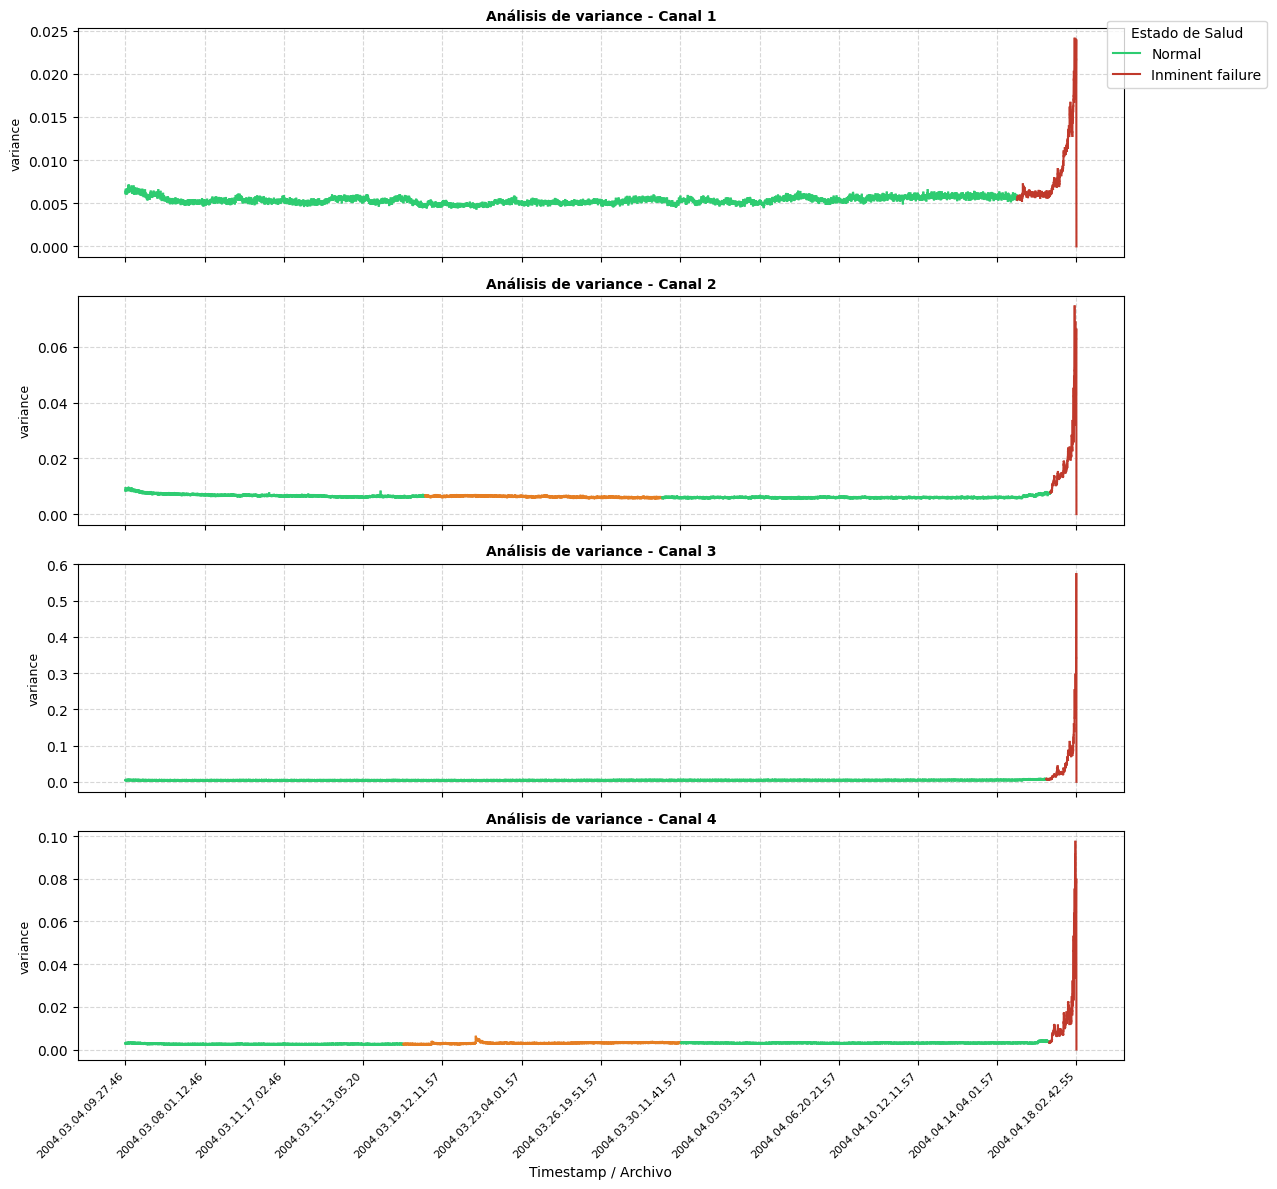

In [ ]:
mostrar_grafica_agrupada(
    df_agregado_3rd_test,
    metrica='variance',
    columna_salud='vida_util',
    columna_canal='canal',
    colores_salud=COLORES_ETIQUETA,
    guardar_figura=True,
    nombre_figura=os.path.join(dir_artifacts, "grafica_agrupada_3rd_test_variance(test).png")
)

## Variables para control de filtrado de features

In [10]:
# VARIABLES PARA WANDB
media_shap = 0
TARGET = "salud_miltos"
DATASET_ANALISIS = "NONE"

ejecutar_analisis_shap = False
ejecutar_analisis_pearson = True
FEATURES_ESCOGIDOS = []
COLUMNAS_CATEGORICAS = ["archivo", "canal", "salud", "salud_miltos"]
COLUMNAS_CATEGORICAS_2nd_test = ["archivo", "canal", "salud", "salud_miltos"]
COLUMNAS_CATEGORICAS_3rd_test = ["archivo", "canal", "vida_util"]


## Análisis de correlación


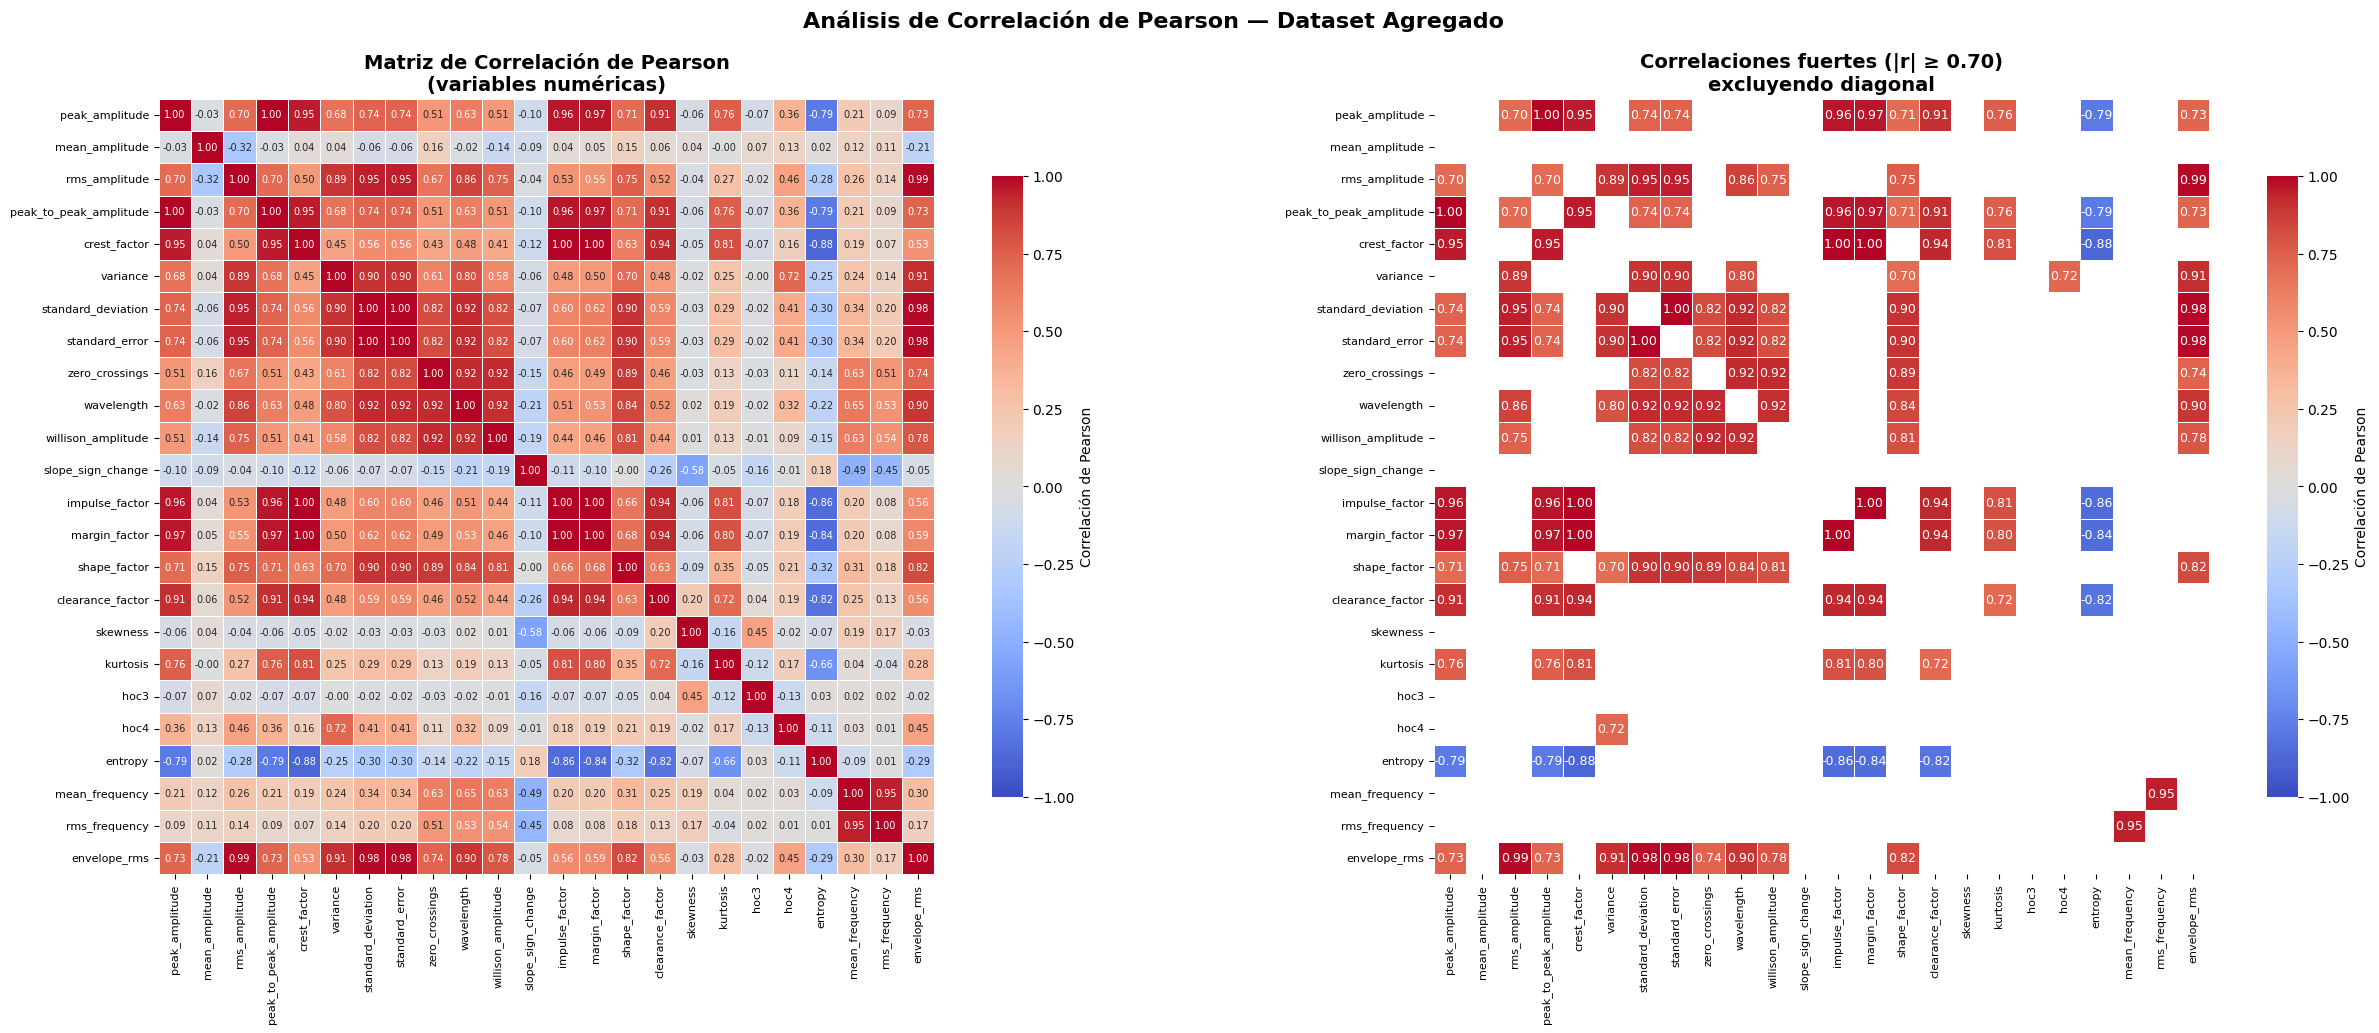

Umbral aplicado : |r| > 0.6
Variables conservadas: ['peak_amplitude', 'mean_amplitude', 'slope_sign_change', 'skewness', 'hoc3']


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if ejecutar_analisis_pearson:
    # ── Parámetros ───────────────────────────────────────────────────────────────
    DATASET_ANALISIS = "Pearson"
    UMBRAL_PEARSON = 0.6  # aquellas parámetros que sobrepasen el umbral de correlación serán eliminados


    # Seleccionar solo columnas numéricas
    df_num = df.select_dtypes(include=[np.number])

    # Calcular matriz de correlación de Pearson
    corr_matrix = df_num.corr(method='pearson')

    # ── Figura ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(26, 10))

    # 1) Heatmap completo
    sns.heatmap(
        corr_matrix,
        ax=axes[0],
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        annot_kws={"size": 7},
        square=True,
        cbar_kws={"shrink": 0.8, "label": "Correlación de Pearson"}
    )
    axes[0].set_title("Matriz de Correlación de Pearson\n(variables numéricas)", fontsize=14, fontweight="bold")
    axes[0].tick_params(axis='x', rotation=90, labelsize=8)
    axes[0].tick_params(axis='y', rotation=0,  labelsize=8)

    # 2) Heatmap de correlaciones fuertes (|r| >= 0.7), excluyendo la diagonal
    mask_weak = (corr_matrix.abs() < 0.7)
    np.fill_diagonal(mask_weak.values, True)   # ocultar diagonal

    sns.heatmap(
        corr_matrix,
        ax=axes[1],
        mask=mask_weak,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        annot_kws={"size": 9},
        square=True,
        cbar_kws={"shrink": 0.8, "label": "Correlación de Pearson"}
    )
    axes[1].set_title("Correlaciones fuertes (|r| ≥ 0.70)\nexcluyendo diagonal", fontsize=14, fontweight="bold")
    axes[1].tick_params(axis='x', rotation=90, labelsize=8)
    axes[1].tick_params(axis='y', rotation=0,  labelsize=8)

    plt.suptitle("Análisis de Correlación de Pearson — Dataset Agregado", fontsize=16, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(dir_artifacts + "/correlacion_pearson.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Identificar columnas a eliminar ─────────────────────────────────────────
    corr_matrix_abs = corr_matrix.abs()
    upper = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))
    # Por cada par correlacionado, se elimina la segunda columna (la de la derecha)
    cols_eliminar = set()
    for col in upper.columns:
        if any(upper[col] > UMBRAL_PEARSON):
            cols_eliminar.add(col)

    FEATURES_ESCOGIDOS = [c for c in df_num.columns if c not in cols_eliminar]

    print(f"Umbral aplicado : |r| > {UMBRAL_PEARSON}")
    print(f"Variables conservadas: {FEATURES_ESCOGIDOS}")


## Análisis de importancia SHAP

In [12]:

if ejecutar_analisis_shap:

    # ── Definir features y target ─────────────────────────────────────────────
    DATASET_ANALISIS = "SHAP"


    feature_cols = [c for c in df.columns if c not in COLUMNAS_CATEGORICAS]

    # Eliminar filas sin target o sin features
    df_model = df[feature_cols + [TARGET]].dropna(subset=[TARGET])
    df_model = df_model.dropna(subset=feature_cols)

    X = df_model[feature_cols]
    y_raw = df_model[TARGET]

    # Codificar target si es categórico
    le = LabelEncoder()
    y = le.fit_transform(y_raw)
    clases = le.classes_
    print(f"Clases detectadas: {clases}")
    print(f"Shape X: {X.shape}  |  distribución y: {pd.Series(y).value_counts().to_dict()}")

    # ── 3. Train / Test split ────────────────────────────────────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # ── 4. Entrenar modelo base (Random Forest) ──────────────────────────────────
    model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    print("\n── Reporte de clasificación ──")
    print(classification_report(y_test, model.predict(X_test), target_names=clases))


    # ── 5. Calcular valores SHAP ─────────────────────────────────────────────────
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    print(f"Tipo shap_values : {type(shap_values)}")
    if isinstance(shap_values, list):
        print(f"Nº clases        : {len(shap_values)}")
        print(f"Shape por clase  : {shap_values[0].shape}")
        is_multiclass = True
    else:
        print(f"Shape shap_values: {shap_values.shape}")
        is_multiclass = False

    # ── 6. DataFrame de importancia global ──────────────────────────────────────
    if is_multiclass:
        # Stack: (n_clases, n_muestras, n_features) → media absoluta sobre clases y muestras
        shap_stack     = np.stack(shap_values, axis=0)          # (n_clases, n_muestras, n_features)
        shap_abs_mean  = np.abs(shap_stack).mean(axis=(0, 1))   # (n_features,)  ← 1-D ✓
        shap_vals_plot = shap_values
    else:
        # Binario: shap_values puede ser (n_muestras, n_features) o (n_muestras, n_features, 2)
        if shap_values.ndim == 3:
            shap_abs_mean = np.abs(shap_values[:, :, 1]).mean(axis=0)   # clase positiva
        else:
            shap_abs_mean = np.abs(shap_values).mean(axis=0)            # (n_features,) ✓
        shap_vals_plot = shap_values

    print(f"shap_abs_mean shape: {shap_abs_mean.shape}")   # debe ser (n_features,)

    importancia = pd.DataFrame({
        "feature"       : feature_cols,
        "shap_mean_abs" : shap_abs_mean          # ya es 1-D, no necesita .mean()
    }).sort_values("shap_mean_abs", ascending=False).reset_index(drop=True)

    importancia["rank"] = importancia.index + 1
    print("\n── Importancia SHAP (global) ──")
    print(importancia.to_string(index=False))

    # ── 7. Visualizaciones ───────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))

    # 7-A  Bar plot de importancia global
    axes[0].barh(
        importancia["feature"][::-1],
        importancia["shap_mean_abs"][::-1],
        color=sns.color_palette("viridis", len(importancia))
    )
    axes[0].set_xlabel("mean(|SHAP value|)", fontsize=11)
    axes[0].set_title("Importancia Global SHAP\n(todas las clases)", fontsize=13, fontweight="bold")
    axes[0].axvline(importancia["shap_mean_abs"].mean(), color="red", linestyle="--", label="Media global")
    axes[0].legend(fontsize=9)

    # 7-B  Beeswarm / Summary plot (usa la API de shap directamente)
    plt.sca(axes[1])
    if is_multiclass:
        # Para multiclase tomamos la clase de mayor índice (la "positiva" o última)
        shap.summary_plot(
            shap_vals_plot[-1], X_test,
            feature_names=feature_cols,
            show=False, plot_size=None, color_bar=True
        )
    else:
        shap.summary_plot(
            shap_vals_plot, X_test,
            feature_names=feature_cols,
            show=False, plot_size=None, color_bar=True
        )
    axes[1].set_title(f"Beeswarm SHAP\n(clase: {clases[-1]})", fontsize=13, fontweight="bold")

    # 7-C  Heatmap: SHAP medio por clase
    if is_multiclass:
        shap_por_clase = pd.DataFrame(
            {cls: np.abs(sv).mean(axis=0) for cls, sv in zip(clases, shap_vals_plot)},
            index=feature_cols
        ).sort_values(by=clases[0], ascending=False)

        sns.heatmap(
            shap_por_clase,
            ax=axes[2],
            cmap="YlOrRd",
            annot=True, fmt=".3f",
            linewidths=0.4,
            cbar_kws={"label": "mean(|SHAP|)"}
        )
        axes[2].set_title("mean(|SHAP|) por clase", fontsize=13, fontweight="bold")
        axes[2].tick_params(axis='x', rotation=30, labelsize=9)
        axes[2].tick_params(axis='y', rotation=0,  labelsize=9)
    else:
        axes[2].axis("off")

    plt.suptitle("Análisis de Importancia de Parámetros — SHAP", fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("shap_importancia.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── 8. Guardar tabla de importancia ─────────────────────────────────────────
    # importancia.to_csv("shap_importancia.csv", index=False)

In [13]:
if ejecutar_analisis_shap:
    # armado de dataset con las clases originales por encima de la media 
    # ── Filtrar features por encima de la media SHAP ────────────────────────────
    # media_shap = importancia["shap_mean_abs"].mean()
    # print(f"Media SHAP global: {media_shap:.4f}")

    # umbral_shap = media_shap  # puedes ajustar este valor según tus necesidades
    umbral_shap = 0.006 # umbral fijo (opcional)

    importancia_filtrada = importancia[importancia["shap_mean_abs"] > umbral_shap].reset_index(drop=True)
    importancia_filtrada["rank"] = importancia_filtrada.index + 1

    print(f"\nFeatures totales         : {len(importancia)}")
    print(f"Features sobre la media  : {len(importancia_filtrada)}")
    print(f"Features descartadas     : {len(importancia) - len(importancia_filtrada)}")
    print("\n── Features seleccionadas ──")
    print(importancia_filtrada.to_string(index=False))

    # ── Construir subconjunto del dataset ────────────────────────────────────────
    cols_seleccionadas = importancia_filtrada["feature"].tolist()
    # OPCIONAL establecerlas manualmente 
    cols_seleccionadas = ['rms_frequency', 'mean_frequency', 'standard_deviation', 'standard_error', 'variance', 'hoc4', 'envelope_rms', 'mean_amplitude', 'kurtosis', 'rms_amplitude', 'wavelength']

    df_cat = df.select_dtypes(exclude=[np.number])
    df_subset = pd.concat([
        df_cat.reset_index(drop=True),
        df[cols_seleccionadas].reset_index(drop=True)
    ], axis=1)

    print(f"\nShape original : {df.shape}")
    print(f"Shape subconjunto: {df_subset.shape}")
    print(f"\nColumnas seleccionadas: {cols_seleccionadas}")

    # ── Visualización ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 6))

    colores = ["steelblue" if v > umbral_shap else "lightgray"
            for v in importancia["shap_mean_abs"]]

    ax.barh(importancia["feature"][::-1], importancia["shap_mean_abs"][::-1], color=colores[::-1])
    ax.axvline(umbral_shap, color="red", linestyle="--", linewidth=1.5, label=f"Umbral = {umbral_shap:.4f}")
    ax.set_xlabel("mean(|SHAP value|)", fontsize=11)
    ax.set_title("Features seleccionadas por encima de la media SHAP\n(azul = seleccionadas, gris = descartadas)",
                fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(dir_artifacts + "/shap_seleccion_media.png", dpi=150, bbox_inches="tight")
    plt.show()

    df = df_subset.copy()  # reasignar para usar el subconjunto en el entrenamiento
    # Guardar (opcional)
    # df_subset.to_csv("dataset_subset_shap.csv", index=False)

## Filtrado de features

In [14]:

if ejecutar_analisis_pearson or ejecutar_analisis_shap:
    # (OPCIONAL) establecer manualmente las features a conservar
    # FEATURES_ESCOGIDOS = ["rms_frequency", "mean_frequency", "standard_deviation", "standard_error", "variance", "hoc4", "envelope_rms", "mean_amplitude", "kurtosis", "rms_amplitude", "wavelength"]

    # ── Reporte ──────────────────────────────────────────────────────────────────
    print(f"Variables conservadas: {len(FEATURES_ESCOGIDOS)}")

    # ── Dataset final (numéricas filtradas + categóricas originales) ─────────────
    df_filtrado = df[COLUMNAS_CATEGORICAS + FEATURES_ESCOGIDOS]  # mantener solo las columnas seleccionadas

    df_agregado_2nd_test_filtrado = df_agregado_2nd_test[COLUMNAS_CATEGORICAS_2nd_test + FEATURES_ESCOGIDOS]
    df_agregado_3rd_test_filtrado = df_agregado_3rd_test[COLUMNAS_CATEGORICAS_3rd_test + FEATURES_ESCOGIDOS]


    print(f"\nShape original : {df.shape}")
    print(f"Shape filtrado : {df_filtrado.shape}")

    df = df_filtrado.copy()  # actualizar df para usar el dataset filtrado en adelante

    df_agregado_2nd_test = df_agregado_2nd_test_filtrado.copy()
    df_agregado_3rd_test = df_agregado_3rd_test_filtrado.copy()
    # Guardar (opcional)
    # df_filtrado.to_csv("../datos/datos_generados/estadisticos_agregados/dataset_filtrado.csv", index=False)

Variables conservadas: 5

Shape original : (17248, 28)
Shape filtrado : (17248, 9)


## Armado de tensores


### Tensores 1st_test

In [15]:
import numpy as np


# codificar canal como número entero
df["canal"] = df["canal"].str.extract(r'(\d+)').astype(int)

# separacion de features y target
features = df.columns.drop(["archivo", "canal", "salud_miltos", "salud"])


experimentos = df["archivo"].unique()

X = []
y = []

for exp in experimentos:
    
    bloque = df[df["archivo"] == exp].sort_values("canal")
    
    # matriz 8 x features
    matriz = bloque[features].values
    
    X.append(matriz)
    
    # target del experimento
    y.append(bloque["salud_miltos"].iloc[0])

X = np.array(X)
y = np.array(y)

print(f"forma de X: {X.shape}")
print(f"forma de y: {y.shape}")

forma de X: (2156, 8, 5)
forma de y: (2156,)


In [16]:
# Codificación de clases 
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)
num_classes = len(le.classes_)

for cls, idx in zip(le.classes_, range(num_classes)):
    print(f"Clase '{cls}' → {idx}")

Clase 'Early' → 0
Clase 'Inminent failure' → 1
Clase 'Normal' → 2
Clase 'Suspect' → 3


In [17]:
# Separación (train + validation + test)

from sklearn.model_selection import train_test_split

# 1. Separación sobre el 100% de los datos en Train (80%) y Test (20%) 
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2. Separación sobre el 80% de los datos en Train (70%) y Valid (10%)
# test_size=0.125 porque 0.125 * 0.8 = 0.1 (10% del total) 
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_temp, y_train_temp, test_size=0.125, random_state=42, stratify=y_train_temp
)

In [18]:
# Estandarización de features 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_train = X_train_scaled.reshape(X_train.shape)


# Para Test
X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])
X_test_scaled = scaler.transform(X_test_reshaped) 
X_test = X_test_scaled.reshape(X_test.shape)

# Para Valid
X_valid_reshaped = X_valid.reshape(-1, X_valid.shape[-1])
X_valid_scaled = scaler.transform(X_valid_reshaped) 
X_valid = X_valid_scaled.reshape(X_valid.shape)

In [19]:
# ====== DATA AUGMENTATION (Opcional) ======

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# ---------- FUNCIONES DE AUGMENTATION ----------
def add_noise(X, noise_level=0.01):
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise

def scaling(X, sigma=0.1):
    factor = np.random.normal(1.0, sigma, (X.shape[0], 1, 1))
    return X * factor

def time_shift(X, shift_max=5):
    X_shifted = np.zeros_like(X)
    for i in range(X.shape[0]):
        shift = np.random.randint(-shift_max, shift_max)
        X_shifted[i] = np.roll(X[i], shift, axis=0)
    return X_shifted

# ---------- IDENTIFICAR CLASE MINORITARIA ----------
classes, counts = np.unique(y_train, return_counts=True)
minority_class = classes[np.argmin(counts)]

# ---------- EXTRAER CLASE MINORITARIA ----------
X_min = X_train[y_train == minority_class]

# ---------- GENERAR DATOS AUMENTADOS ----------
X_aug = add_noise(X_min)
X_aug = np.concatenate([
    X_aug,
    scaling(X_min),
    time_shift(X_min)
])

y_aug = np.full(len(X_aug), minority_class)

# ---------- COMBINAR DATASET ----------
X_train = np.concatenate([X_train, X_aug])
y_train = np.concatenate([y_train, y_aug])

# ---------- CALCULAR CLASS WEIGHT ----------
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight = dict(zip(np.unique(y_train), weights))

# ---------- INFO DEBUG ----------
print("Shape original:", X_train.shape)
print("Shape final:", X_train.shape)
print("Distribución original:", dict(zip(classes, counts)))
print("Distribución nueva:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Class weights:", class_weight)


Shape original: (1625, 8, 5)
Shape final: (1625, 8, 5)
Distribución original: {0: 105, 1: 39, 2: 630, 3: 734}
Distribución nueva: {0: 105, 1: 156, 2: 630, 3: 734}
Class weights: {0: 3.869047619047619, 1: 2.6041666666666665, 2: 0.6448412698412699, 3: 0.5534741144414169}


In [20]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1625, 8, 5), (1625,), (432, 8, 5), (432,))

### Tensores de 2nd_test

In [21]:
import numpy as np


# codificar canal como número entero, para mantenerlo como feature en el modelo
df_agregado_2nd_test_copy = df_agregado_2nd_test.copy()
df_agregado_2nd_test_copy["canal"] = df_agregado_2nd_test_copy["canal"].str.extract(r'(\d+)').astype(int)

# separacion de features y target
features = df_agregado_2nd_test_copy.columns.drop(["archivo", "canal", "salud_miltos", "salud"])

# features escogidos manualmente 
experimentos = df_agregado_2nd_test_copy.loc[:, FEATURES_ESCOGIDOS]
experimentos = df_agregado_2nd_test_copy["archivo"].unique()

X_2nd_test = []
y_2nd_test = []

for exp in experimentos:
    
    bloque = df_agregado_2nd_test_copy[df_agregado_2nd_test_copy["archivo"] == exp].sort_values("canal")
    
    # matriz 8 x features
    matriz = bloque[features].values
    
    X_2nd_test.append(matriz)
    
    # target del experimento
    y_2nd_test.append(bloque["salud_miltos"].iloc[0])

X_2nd_test = np.array(X_2nd_test)
y_2nd_test = np.array(y_2nd_test)

print(X_2nd_test.shape)
print(y_2nd_test.shape)

(2156, 8, 5)
(2156,)


In [22]:
# codificacion de clases 
from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()
y_2nd_test = le.transform(y_2nd_test)


In [23]:
# estandarización de features (usar el mismo scaler que para el entrenamiento)
scaler = StandardScaler()

# Sólo Test
X_2nd_test_reshaped = X_2nd_test.reshape(-1, X_2nd_test.shape[-1])
X_2nd_test_scaled = scaler.fit_transform(X_2nd_test_reshaped)
X_2nd_test = X_2nd_test_scaled.reshape(X_2nd_test.shape)


In [24]:
# X_train.shape, y_train.shape, X_test.shape, y_test.shape
X_2nd_test.shape, y_2nd_test.shape

((2156, 8, 5), (2156,))

### Tensores de 3er_test

In [25]:

# codificar canal como número entero, para mantenerlo como feature en el modelo
df_agregado_3rd_test_copy = df_agregado_3rd_test.copy()

# duplicar canales para tener 8 filas por experimento (si no las tiene ya)
nuevos_canales_list = []
for i in range(0, len(df_agregado_3rd_test_copy), 4):
    bloque_original = df_agregado_3rd_test_copy.iloc[i : i + 4].copy()
    nuevo_bloque = bloque_original.copy()
    mapeo_canales = {
        "Canal 1": "Canal 5",
        "Canal 2": "Canal 6",
        "Canal 3": "Canal 7",
        "Canal 4": "Canal 8"
    }
    nuevo_bloque["canal"] = nuevo_bloque["canal"].map(mapeo_canales)
    nuevos_canales_list.append(nuevo_bloque)

df_nuevos_canales = pd.concat(nuevos_canales_list, ignore_index=True)
df_agregado_3rd_test_copy = pd.concat([df_agregado_3rd_test_copy, df_nuevos_canales], ignore_index=True)
df_agregado_3rd_test_copy = df_agregado_3rd_test_copy.sort_values(by=["archivo", "canal"]).reset_index(drop=True)

df_agregado_3rd_test_copy["canal"] = df_agregado_3rd_test_copy["canal"].str.extract(r'(\d+)').astype(int)

# separacion de features y target
features = df_agregado_3rd_test_copy.columns.drop(["archivo", "canal", "vida_util"])

# features escogidos manualmente 
experimentos = df_agregado_3rd_test_copy.loc[:, FEATURES_ESCOGIDOS]
experimentos = df_agregado_3rd_test_copy["archivo"].unique()

X_3rd_test = []
y_3rd_test = []

for exp in experimentos:
    
    bloque = df_agregado_3rd_test_copy[df_agregado_3rd_test_copy["archivo"] == exp].sort_values("canal")
    
    # matriz 8 x features
    matriz = bloque[features].values
    
    X_3rd_test.append(matriz)
    
    # target del experimento
    y_3rd_test.append(bloque["vida_util"].iloc[0])

X_3rd_test = np.array(X_3rd_test)
y_3rd_test = np.array(y_3rd_test)

print(X_3rd_test.shape)
print(y_3rd_test.shape)

(6324, 8, 5)
(6324,)


In [26]:
# codificacion de clases 
from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()
y_3rd_test = le.transform(y_3rd_test)


In [27]:
# Normalización de features (usar el mismo scaler que para el entrenamiento)
scaler = StandardScaler()

# Sólo Test
X_3rd_test_reshaped = X_3rd_test.reshape(-1, X_3rd_test.shape[-1])
X_3rd_test_scaled = scaler.fit_transform(X_3rd_test_reshaped) 
X_3rd_test = X_3rd_test_scaled.reshape(X_3rd_test.shape)


In [28]:
# X_train.shape, y_train.shape, X_3rd_test.shape, y_3rd_test.shape
X_3rd_test.shape, y_3rd_test.shape

((6324, 8, 5), (6324,))

# Config Wandb (dataset)

In [ ]:
# variable para controlar si usar o no wandb
usar_wandb = True


# guardar datos del dataset
if usar_wandb:
    #diccionario con los parámetros del dataset
    config_params_dataset = {
        "dataset/num_samples" : len(df),
        "dataset/num_features": len(features),
        "dataset/num_classes" : len(le.classes_),
        "dataset/features"    : features.tolist(),
        "dataset/target"      : TARGET,
        "dataset/analysis"    : DATASET_ANALISIS,
        "dataset/shap_mean_threshold": umbral_shap,
        "data_test1/name": df_agregado_2nd_test_name,
        "data_test2/name": df_agregado_3rd_test_name,
    }
    # Crear un artefacto para datos del dataset
    dataset_artifact = wandb.Artifact(
        name="IMS_agregado_filtrado_shap_v1", 
        type="dataset",
        description="Dataset tras eliminar variables con valor de importancia SHAP por debajo de la media global."
    )

    # Crear un artefacto las graficas generadas en el análisis
    figures_artifact = wandb.Artifact(
        name="IMS_graficas_analisis_v1", 
        type="figures",
        description="Graficas generadas en el análisis de los datos."
    )

    # 2. Función auxiliar para evitar errores de rutas y archivos inexistentes
    def agregar_si_existe(ruta_carpeta, nombre_archivo, artefacto):
        ruta_completa = os.path.join(ruta_carpeta, nombre_archivo)
        if os.path.exists(ruta_completa):
            # name= especifica cómo se llamará el archivo DENTRO de wandb
            artefacto.add_file(ruta_completa, name=nombre_archivo)
        else:
            print(f"⚠️ Advertencia: No se encontró el archivo en {ruta_completa}")

    # guardar imagenes de las graficas de SHAP y Pearson si aplica 
    if ejecutar_analisis_pearson:
        agregar_si_existe(dir_artifacts, "correlacion_pearson.png", figures_artifact)
    if ejecutar_analisis_shap:
        agregar_si_existe(dir_artifacts, "shap_importance.png", figures_artifact)

    # guardar graficas agrupadas del estadisticos seleccionados por canal y salud
    agregar_si_existe(dir_artifacts, "grafica_agrupada_1st_test_variance(train).png", figures_artifact)
    agregar_si_existe(dir_artifacts, "grafica_agrupada_2nd_test_variance(test).png", figures_artifact)
    agregar_si_existe(dir_artifacts, "grafica_agrupada_3rd_test_variance(test).png", figures_artifact)


In [ ]:
import os
import wandb

# variable para controlar si usar o no wandb
usar_wandb = True

# guardar datos del dataset
if usar_wandb:
    # 1. Asegúrate de tener un run activo (si no lo has iniciado antes)
    # wandb.init(project="tu_proyecto", config=config_params_dataset)

    # Crear un artefacto para el dataset
    dataset_artifact = wandb.Artifact(
        name="IMS_agregado_filtrado_shap_v1", 
        type="dataset",
        description="Dataset tras eliminar variables con valor de importancia SHAP por debajo de la media global."
    )

    # Crear un artefacto las graficas generadas en el análisis
    figures_artifact = wandb.Artifact(
        name="IMS_graficas_analisis_v1", 
        type="figures",
        description="Graficas generadas en el análisis de los datos."
    )

    # 2. Función auxiliar para evitar errores de rutas y archivos inexistentes
    def agregar_si_existe(ruta_carpeta, nombre_archivo, artefacto):
        ruta_completa = os.path.join(ruta_carpeta, nombre_archivo)
        if os.path.exists(ruta_completa):
            # name= especifica cómo se llamará el archivo DENTRO de wandb
            artefacto.add_file(ruta_completa, name=nombre_archivo)
        else:
            print(f"⚠️ Advertencia: No se encontró el archivo en {ruta_completa}")

    # guardar imagenes de las graficas de SHAP y Pearson si aplica 
    if ejecutar_analisis_pearson:
        agregar_si_existe(dir_artifacts, "correlacion_pearson.png", figures_artifact)
    if ejecutar_analisis_shap:
        agregar_si_existe(dir_artifacts, "shap_importance.png", figures_artifact)

    # guardar graficas agrupadas del estadisticos seleccionados por canal y salud
    agregar_si_existe(dir_artifacts, "grafica_agrupada_1st_test_variance(train).png", figures_artifact)
    agregar_si_existe(dir_artifacts, "grafica_agrupada_2nd_test_variance(test).png", figures_artifact)
    agregar_si_existe(dir_artifacts, "grafica_agrupada_3rd_test_variance(test).png", figures_artifact)


# Arbol de clasificación (XGBoost)

Este modelo no estaba previsto para realizar entremientos, sin embargo, es ampliamente conocido por su sencillez y excelente desempleño con datos tabulares por lo que se decidió realizar un entrenamiento para observar los resultados y comparar.

In [50]:
# Dado que este modelo espera una entrada 2D, necesitamos aplanar cada muestra de 8xfeatures a un vector de features. Esto se hace con reshape, manteniendo el número de muestras (X_train.shape[0]) y aplanando el resto (-1).
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d  = X_test.reshape(X_test.shape[0], -1)
X_valid_2d = X_valid.reshape(X_valid.shape[0], -1)


# conjuntos de testing también aplanados
X_2nd_test_2d = X_2nd_test.reshape(X_2nd_test.shape[0], -1)
X_3rd_test_2d = X_3rd_test.reshape(X_3rd_test.shape[0], -1)


print(X_train_2d.shape)  # (1625, 40)
print(X_test_2d.shape)   # (432, 40)
print(X_valid_2d.shape)  # (216, 40)

(1625, 40)
(432, 40)
(216, 40)


In [51]:


param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [6, 7, 8],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

param_grid = {
    "n_estimators": [300],
    "learning_rate": [0.1],
    "max_depth": [7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

eval_metric = "mlogloss"  # métrica de evaluación para clasificación multiclase

xgb_clf = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_),
    # num_class=len(classes),
    eval_metric=eval_metric,
    use_label_encoder=False,
    random_state=42,
    
)

grid = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring="precision_macro",
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train_2d, y_train)


Fitting 3 folds for each of 4 candidates, totalling 12 fits


/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [23:13:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [23:13:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [23:13:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.

[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.8; total time=   4.1s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=1.0; total time=   4.3s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.8; total time=   4.5s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=1.0; total time=   4.6s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.8; total time=   4.8s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.8; total time=   4.8s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=1.0; total time=   4.8s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=1.0; total time=   4.8s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=300,

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [23:14:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constrain...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_class=4, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.1],
                         'max_depth': [7], 'n_estimators': [300],
                         'subsample': [0.8, 1.0]},
             scoring='precision_macro', verbose=2)

In [52]:
print("Mejor Precision macro CV:", grid.best_score_)
print("Mejores hiperparámetros:", grid.best_params_)

if usar_wandb:
    config_params = {f"param_{k}": v for k, v in grid.best_params_.items()}
    config_params["param_"+"metrica_evaluacion"] = eval_metric

Mejor Precision macro CV: 0.9261493394205172
Mejores hiperparámetros: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}


In [53]:
if usar_wandb:
    # Iniciar run de wandb
    timestap_str = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M")
    run = wandb.init(
        entity="maanmuri-marck",
        project="TF_CEIA_Clasificador_Vibraciones",
        name=f"XGBoost_Agregados_v6_{timestap_str}",
        tags=["xgboost", "gridsearchcv", "precision_macro"],
        config={**config_params, **config_params_dataset}
    )
    run.log_artifact(dataset_artifact)
    run.log_artifact(figures_artifact)



In [54]:
# guardar el modelo entrenado con los mejores hiperparámetros
best_model = grid.best_estimator_
best_model.save_model(f"{dir_artifacts}/xgboost_mejorado.json")

# guardar en wandb el modelo como artefacto
if usar_wandb:
    artifact = wandb.Artifact("xgboost_mejorado", type="model")
    artifact.add_file(f"{dir_artifacts}/xgboost_mejorado.json")
    run.log_artifact(artifact)

## Evaluación - Validation

In [55]:
best_model = grid.best_estimator_

y_valid_pred = best_model.predict(X_valid_2d)

In [56]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "validation/precision": precision,
        "validation/recall": recall,
        "validation/f1_score": f1
    })

Accuracy: 0.9351851851851852
                  precision    recall  f1-score   support

           Early       1.00      1.00      1.00        15
Inminent failure       0.67      0.67      0.67         6
          Normal       0.95      0.93      0.94        90
         Suspect       0.93      0.94      0.93       105

        accuracy                           0.94       216
       macro avg       0.89      0.89      0.89       216
    weighted avg       0.94      0.94      0.94       216



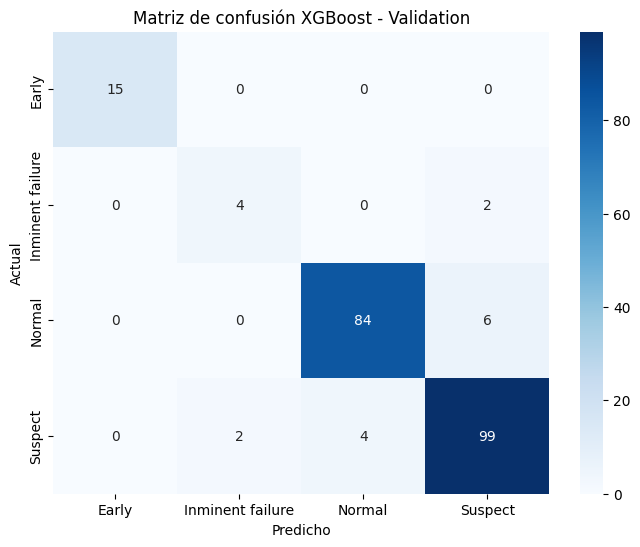

In [57]:

cm = confusion_matrix(y_valid, y_valid_pred)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.title("Matriz de confusión XGBoost - Validation")
plt.ylabel("Actual")
plt.xlabel("Predicho")
plt.savefig(f"{dir_artifacts}/matriz_confusion_xgboost_validacion.png", dpi=300, bbox_inches='tight')

if usar_wandb:
    wandb.log({"matriz_confusion_xgboost_validacion": wandb.Image(plt)})
    
plt.show()

## Evaluación - Test


### 1st_test
Se empleo el subconjunto 10% del dataset empleado para el entrenamiento

In [58]:
best_model = grid.best_estimator_

y_test_pred = best_model.predict(X_test_2d)

In [59]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='weighted')

    wandb.log({
        "test/precision": precision,
        "test/recall": recall,
        "test/f1_score": f1
    })

Accuracy: 0.9143518518518519
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       0.82      0.82      0.82        11
          Normal       0.92      0.90      0.91       180
         Suspect       0.91      0.92      0.91       211

        accuracy                           0.91       432
       macro avg       0.90      0.91      0.91       432
    weighted avg       0.91      0.91      0.91       432



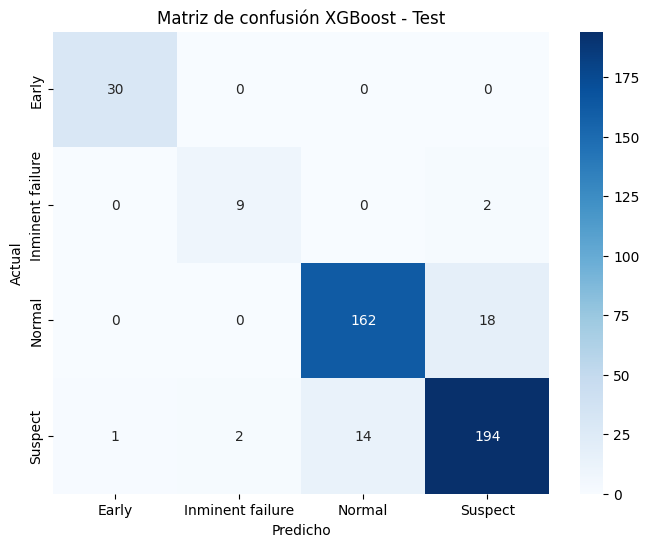

In [60]:

cm = confusion_matrix(y_test, y_test_pred)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.title("Matriz de confusión XGBoost - Test")
plt.ylabel("Actual")
plt.xlabel("Predicho")
plt.savefig(f"{dir_artifacts}/matriz_confusion_xgboost_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_xgboost_test": wandb.Image(plt)})
plt.show()

### 2_test
Se empleo el dataset 2nd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [61]:
best_model = grid.best_estimator_

y_2nd_test_pred = best_model.predict(X_2nd_test_2d)

In [62]:

print("Accuracy:", accuracy_score(y_2nd_test, y_2nd_test_pred))

print(classification_report(
    y_2nd_test,
    y_2nd_test_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_2nd_test, y_2nd_test_pred, average='weighted')

    wandb.log({
        "2nd_test/precision": precision,
        "2nd_test/recall": recall,
        "2nd_test/f1_score": f1
    })

Accuracy: 0.9730983302411874
                  precision    recall  f1-score   support

           Early       0.98      1.00      0.99       150
Inminent failure       0.90      0.95      0.92        56
          Normal       0.98      0.97      0.97       900
         Suspect       0.97      0.97      0.97      1050

        accuracy                           0.97      2156
       macro avg       0.96      0.97      0.96      2156
    weighted avg       0.97      0.97      0.97      2156



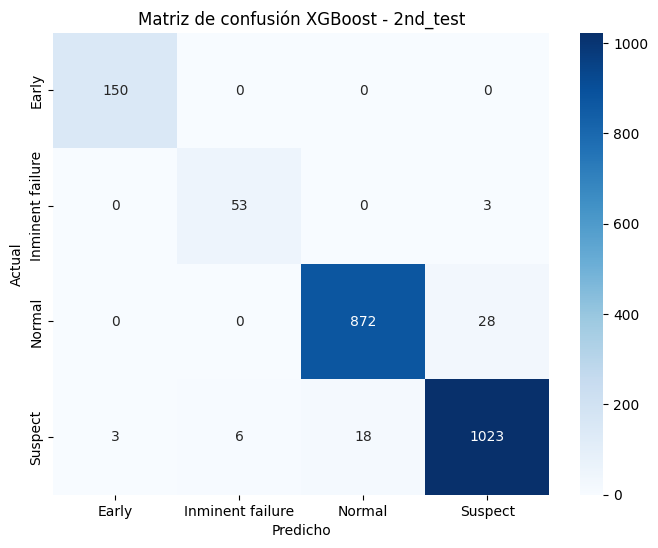

In [63]:
cm = confusion_matrix(y_2nd_test, y_2nd_test_pred)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.title("Matriz de confusión XGBoost - 2nd_test")
plt.ylabel("Actual")
plt.xlabel("Predicho")
plt.savefig(f"{dir_artifacts}/matriz_confusion_xgboost_2nd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_xgboost_2nd_test": wandb.Image(plt)})
plt.show()

### 3rd_test
Se empleo el dataset 3rd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [64]:
best_model = grid.best_estimator_

y_3rd_test_pred = best_model.predict(X_3rd_test_2d)

In [65]:

print("Accuracy:", accuracy_score(y_3rd_test, y_3rd_test_pred))

print(classification_report(
    y_3rd_test,
    y_3rd_test_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_3rd_test, y_3rd_test_pred, average='weighted')

    wandb.log({
        "3rd_test/precision": precision,
        "3rd_test/recall": recall,
        "3rd_test/f1_score": f1
    })

Accuracy: 0.7988614800759013
                  precision    recall  f1-score   support

           Early       0.00      0.00      0.00         0
Inminent failure       0.25      0.64      0.36       395
          Normal       0.97      0.81      0.88      5929
         Suspect       0.00      0.00      0.00         0

        accuracy                           0.80      6324
       macro avg       0.31      0.36      0.31      6324
    weighted avg       0.93      0.80      0.85      6324



/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples

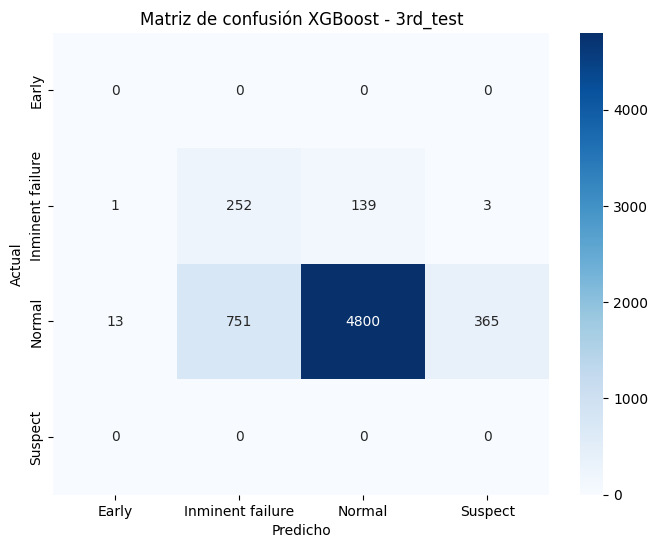

In [66]:
cm = confusion_matrix(y_3rd_test, y_3rd_test_pred)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.title("Matriz de confusión XGBoost - 3rd_test")
plt.ylabel("Actual")
plt.xlabel("Predicho")
plt.savefig(f"{dir_artifacts}/matriz_confusion_xgboost_3rd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_xgboost_3rd_test": wandb.Image(plt)})
plt.show()

In [67]:
# Finalizar la ejecución
if usar_wandb:
    run.finish()

2nd_test/f1_score,▁
2nd_test/precision,▁
2nd_test/recall,▁
3rd_test/f1_score,▁
3rd_test/precision,▁
3rd_test/recall,▁
test/f1_score,▁
test/precision,▁
test/recall,▁
validation/f1_score,▁
+2,...


In [68]:
# Finalizar la ejecución
if usar_wandb:
    run.finish()

# MK - CNN


In [45]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Flatten, Dropout

def make_build_model(X, num_classes):
    def build_model(hp):
        model = Sequential([
            Conv1D(
                filters=hp.Int('filters_1', min_value=16, max_value=128, step=16),
                kernel_size=hp.Choice('kernel_size_1', values=[2, 3, 5]),
                activation="relu",
                padding='same',
                input_shape=(X.shape[1], X.shape[2])
            ),
            MaxPooling1D(pool_size=2),
            Conv1D(
                filters=hp.Int('filters_2', min_value=32, max_value=256, step=32),
                kernel_size=hp.Choice('kernel_size_2', values=[2, 3, 5]),
                activation="relu",
                padding='same'
            ),
            Flatten(),
            Dense(
                units=hp.Int('dense_units', min_value=32, max_value=256, step=32),
                activation="relu"
            ),
            Dropout(
                rate=hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)
            ),
            Dense(num_classes, activation="softmax")
        ])
        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
            ),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy', F1MacroScore(num_classes=num_classes)]
        )
        return model
    return build_model

# Uso — pasás X_train y num_classes acá
eval_metric = "val_f1_score" 
tuner = kt.Hyperband(
    make_build_model(X_train, len(np.unique(y_train))),  
    objective=kt.Objective(eval_metric, direction='max'),
    max_epochs=40,
    factor=3,
    directory='kt_results',
    project_name='cnn_vibraciones'
)

# Callback para detener early si no mejora
stop_early_monitor = 'val_loss'  
stop_early = tf.keras.callbacks.EarlyStopping(monitor=stop_early_monitor, patience=5)

# Búsqueda de hiperparámetros
tuner.search(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early]
)

# Ver resumen de los mejores resultados
tuner.results_summary()

# Obtener el mejor modelo
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  filters_1:   {best_hps.get('filters_1')}
  filters_2:   {best_hps.get('filters_2')}
  kernel_1:    {best_hps.get('kernel_size_1')}
  kernel_2:    {best_hps.get('kernel_size_2')}
  dense_units: {best_hps.get('dense_units')}
  dropout:     {best_hps.get('dropout')}
  lr:          {best_hps.get('lr')}
""")

if usar_wandb:
    config_params = {f"param_{k}": v for k, v in best_hps.values.items()}
    config_params["param_metrica_evaluacion"] = eval_metric
    config_params["param_stop_early_monitor"] = stop_early_monitor


Reloading Tuner from kt_results/cnn_vibraciones/tuner0.json
Results summary
Results in kt_results/cnn_vibraciones
Showing 10 best trials
Objective(name="val_f1_score", direction="max")

Trial 0067 summary
Hyperparameters:
filters_1: 128
kernel_size_1: 3
filters_2: 64
kernel_size_2: 2
dense_units: 32
dropout: 0.4
lr: 0.0015980108835268547
tuner/epochs: 14
tuner/initial_epoch: 5
tuner/bracket: 2
tuner/round: 1
tuner/trial_id: 0056
Score: 0.9618614912033081

Trial 0084 summary
Hyperparameters:
filters_1: 128
kernel_size_1: 5
filters_2: 32
kernel_size_2: 3
dense_units: 64
dropout: 0.2
lr: 0.00025529484165240227
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0079
Score: 0.9582096338272095

Trial 0077 summary
Hyperparameters:
filters_1: 64
kernel_size_1: 3
filters_2: 192
kernel_size_2: 3
dense_units: 160
dropout: 0.5
lr: 0.001800627430497124
tuner/epochs: 14
tuner/initial_epoch: 0
tuner/bracket: 1
tuner/round: 0
Score: 0.9566235542297363

Trial 0048 

In [ ]:
if usar_wandb:
    # Iniciar run de wandb
    timestap_str = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M")
    run = wandb.init(
        entity="maanmuri-marck",
        project="TF_CEIA_Clasificador_Vibraciones",
        name=f"CNN_Agregados_v6_{timestap_str}",
        tags=["cnn", "hyperparameter_tuning", "precision_macro"],
        config={**config_params, **config_params_dataset}

    )
    run.log_artifact(dataset_artifact)

wandb: WARNING Artifact "IMS_agregado_filtrado_shap_v1" already exists with the same content. No new version will be created.


In [47]:
# Entrenar el modelo final con los mejores hiperparámetros
callbacks_list = [stop_early]

if usar_wandb:
    callbacks_list.append(WandbMetricsLogger())
    callbacks_list.append(WandbModelCheckpoint(
    filepath=f"{dir_artifacts}/best_cnn_model.keras", 
    monitor=stop_early_monitor, 
    save_best_only=True,
    load_weights_on_restart=True
))

best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_data=(X_valid, y_valid),
    callbacks=callbacks_list
)

wandb: WARNING When using `save_best_only`, ensure that the `filepath` argument contains formatting placeholders like `{epoch:02d}` or `{batch:02d}`. This ensures correct interpretation of the logged artifacts.
2026-05-16 16:21:10.820955: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Epoch 1/40
204/204 [==============================] - 2s 4ms/step - loss: 0.7196 - accuracy: 0.7194 - f1_score: 0.7062 - val_loss: 0.4545 - val_accuracy: 0.8056 - val_f1_score: 0.8282
Epoch 2/40
204/204 [==============================] - 1s 4ms/step - loss: 0.4480 - accuracy: 0.8326 - f1_score: 0.8412 - val_loss: 0.3838 - val_accuracy: 0.8472 - val_f1_score: 0.8762
Epoch 3/40
204/204 [==============================] - 1s 3ms/step - loss: 0.3962 - accuracy: 0.8431 - f1_score: 0.8572 - val_loss: 0.4103 - val_accuracy: 0.8657 - val_f1_score: 0.8708
Epoch 4/40
204/204 [==============================] - 1s 5ms/step - loss: 0.3627 - accuracy: 0.8634 - f1_score: 0.8825 - val_loss: 0.4781 - val_accuracy: 0.8287 - val_f1_score: 0.8839
Epoch 5/40
204/204 [==============================] - 1s 3ms/step - loss: 0.3451 - accuracy: 0.8628 - f1_score: 0.8852 - val_loss: 0.4234 - val_accuracy: 0.8565 - val_f1_score: 0.8663
Epoch 6/40
204/204 [==============================] - 1s 3ms/step - loss: 0.3118

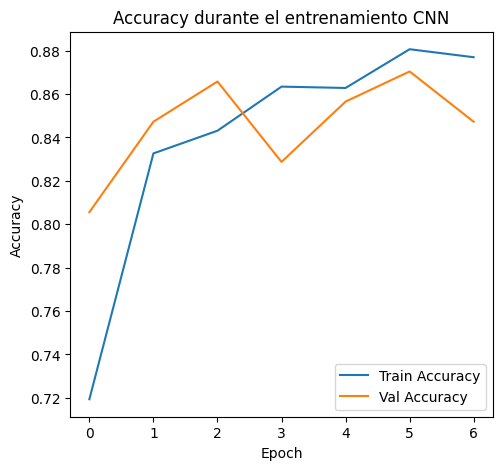

In [48]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento CNN')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.savefig(f"{dir_artifacts}/accuracy_epoch_cnn.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"accuracy_epoch_cnn_validacion": wandb.Image(plt)})
    
plt.legend()

In [49]:
# guardar el modelo entrenado 
best_model.save(f"{dir_artifacts}/best_cnn_model.h5", save_format='h5')

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluación - Validation

In [50]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_valid_pred = best_model.predict(X_valid)
y_valid_pred = np.argmax(y_valid_pred, axis=1)

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "validation/precision": precision,
        "validation/recall": recall,
        "validation/f1_score": f1
    })

7/7 [==============================] - 0s 2ms/step
Accuracy: 0.8472222222222222
                  precision    recall  f1-score   support

           Early       1.00      1.00      1.00        15
Inminent failure       0.33      0.83      0.48         6
          Normal       0.94      0.81      0.87        90
         Suspect       0.83      0.86      0.85       105

        accuracy                           0.85       216
       macro avg       0.78      0.88      0.80       216
    weighted avg       0.87      0.85      0.86       216



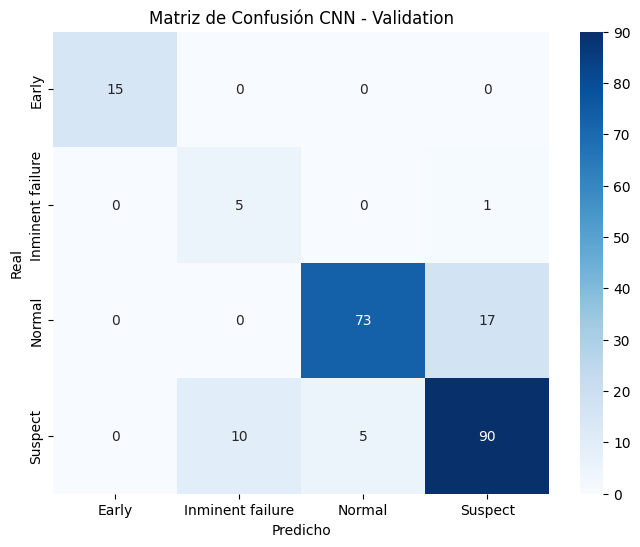

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión CNN - Validation")
plt.savefig(f"{dir_artifacts}/matriz_confusion_cnn_validation.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_cnn_validation": wandb.Image(plt)})
    
plt.show()

## Evaluacion - Test

### 1st_test (subconjunto 10%)
Se empleo el subconjunto 10% del dataset empleado para el entrenamiento

In [52]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_test_pred = best_model.predict(X_test)
y_test_pred = np.argmax(y_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "test/precision": precision,
        "test/recall": recall,
        "test/f1_score": f1
    })

14/14 [==============================] - 0s 2ms/step
Accuracy: 0.8101851851851852
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       0.26      0.91      0.41        11
          Normal       0.87      0.80      0.83       180
         Suspect       0.84      0.79      0.81       211

        accuracy                           0.81       432
       macro avg       0.74      0.87      0.76       432
    weighted avg       0.85      0.81      0.82       432



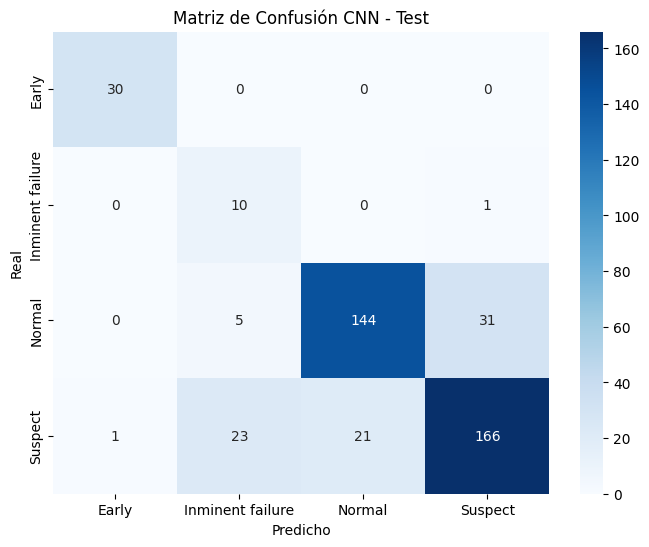

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión CNN - Test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_cnn_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_cnn_test": wandb.Image(plt)})
    
plt.show()

### 2_test
Se empleo el dataset 2nd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [54]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_2nd_test_pred = best_model.predict(X_2nd_test)
y_2nd_test_pred = np.argmax(y_2nd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_2nd_test, y_2nd_test_pred))

print(classification_report(
    y_2nd_test,
    y_2nd_test_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_2nd_test, y_2nd_test_pred, average='weighted')

    wandb.log({
        "2nd_test/precision": precision,
        "2nd_test/recall": recall,
        "2nd_test/f1_score": f1
    })

68/68 [==============================] - 0s 1ms/step
Accuracy: 0.8515769944341373
                  precision    recall  f1-score   support

           Early       0.96      1.00      0.98       150
Inminent failure       0.35      0.96      0.51        56
          Normal       0.90      0.85      0.88       900
         Suspect       0.87      0.82      0.85      1050

        accuracy                           0.85      2156
       macro avg       0.77      0.91      0.80      2156
    weighted avg       0.88      0.85      0.86      2156



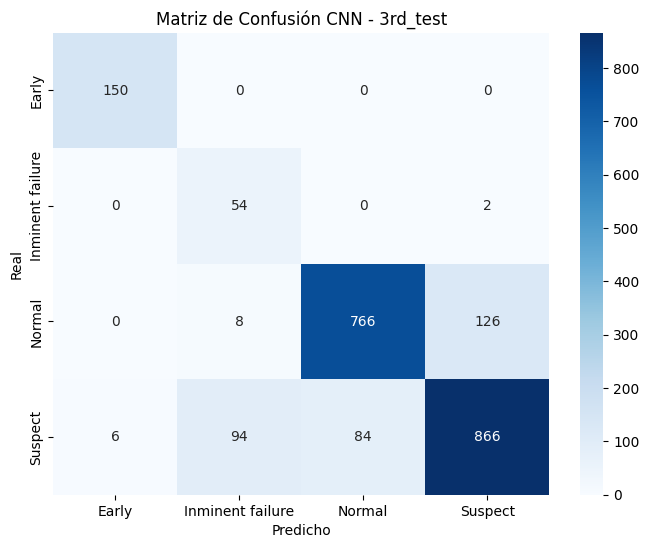

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_2nd_test, y_2nd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión CNN - 3rd_test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_cnn_3rd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_cnn_3rd_test": wandb.Image(plt)})
    
plt.show()

### 3rd_test
Se empleo el dataset 3rd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [56]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_3rd_test_pred = best_model.predict(X_3rd_test)
y_3rd_test_pred = np.argmax(y_3rd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_3rd_test, y_3rd_test_pred))

print(classification_report(
    y_3rd_test,
    y_3rd_test_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_3rd_test, y_3rd_test_pred, average='weighted')

    wandb.log({
        "3rd_test/precision": precision,
        "3rd_test/recall": recall,
        "3rd_test/f1_score": f1
    })

198/198 [==============================] - 0s 1ms/step
Accuracy: 0.7729285262492094
                  precision    recall  f1-score   support

           Early       0.00      0.00      0.00         0
Inminent failure       0.29      0.38      0.33       395
          Normal       0.97      0.80      0.88      5929
         Suspect       0.00      0.00      0.00         0

        accuracy                           0.77      6324
       macro avg       0.31      0.30      0.30      6324
    weighted avg       0.93      0.77      0.84      6324



/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples

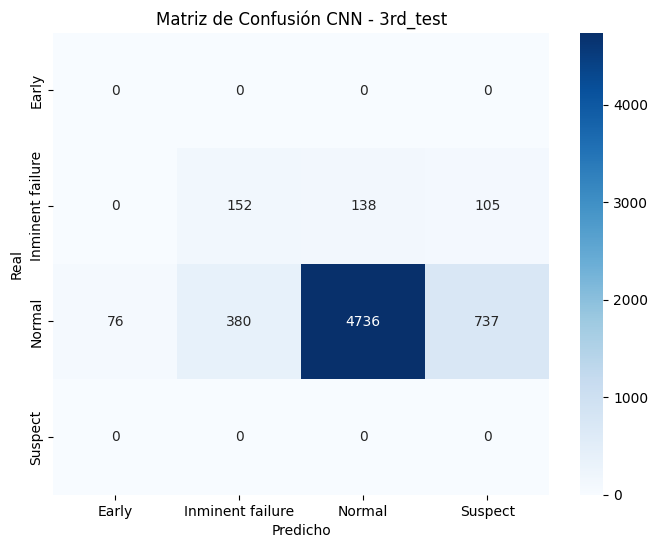

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_3rd_test, y_3rd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión CNN - 3rd_test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_cnn_3rd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_cnn_3rd_test": wandb.Image(plt)})
    
plt.show()

In [58]:
# Finalizar la ejecución
if usar_wandb:
    run.finish()

2nd_test/f1_score,▁
2nd_test/precision,▁
2nd_test/recall,▁
3rd_test/f1_score,▁
3rd_test/precision,▁
3rd_test/recall,▁
epoch/accuracy,▁▆▆▇▇██
epoch/epoch,▁▂▃▅▆▇█
epoch/f1_score,▁▆▆▇▇██
epoch/learning_rate,▁▁▁▁▁▁▁
+10,...


# RNN


In [61]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

def make_build_model(X_train, num_classes):
    def build_model(hp):
        model = Sequential([

            SimpleRNN(
                units=hp.Int('rnn_units_1', min_value=32, max_value=256, step=32),
                return_sequences=True,
                input_shape=(X_train.shape[1], X_train.shape[2])
            ),

            Dropout(
                rate=hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)
            ),

            SimpleRNN(
                units=hp.Int('rnn_units_2', min_value=16, max_value=128, step=16)
            ),

            Dense(
                units=hp.Int('dense_units', min_value=32, max_value=256, step=32),
                activation="relu"
            ),

            Dense(num_classes, activation="softmax")
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
            ),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy",
                # tf.keras.metrics.Precision(name='precision'),
                # tf.keras.metrics.Recall(name='recall'),
                F1MacroScore(num_classes=num_classes)]
        )

        return model
    return build_model

eval_metric = "val_f1_score"  # nombre de la métrica personalizada que definimos
tuner = kt.Hyperband(
    make_build_model(X_train, num_classes),
    objective=kt.Objective(eval_metric, direction='max'),
    max_epochs=40,
    factor=3,
    directory='kt_results',
    project_name='rnn_vibraciones'
)

stop_early_monitor = 'val_loss'  # o 'val_f1_score' si querés monitorear la métrica personalizada
stop_early = tf.keras.callbacks.EarlyStopping(monitor=stop_early_monitor, patience=5)

tuner.search(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early]
)

tuner.results_summary()

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  rnn_units_1: {best_hps.get('rnn_units_1')}
  rnn_units_2: {best_hps.get('rnn_units_2')}
  dropout:     {best_hps.get('dropout_1')}
  dense_units: {best_hps.get('dense_units')}
  lr:          {best_hps.get('lr')}
""")

if usar_wandb:
    config_params = {f"param_{k}": v for k, v in best_hps.values.items()}
    config_params["param_metrica_evaluacion"] = eval_metric
    config_params["param_stop_early_monitor"] = stop_early_monitor



Reloading Tuner from kt_results/rnn_vibraciones/tuner0.json
Results summary
Results in kt_results/rnn_vibraciones
Showing 10 best trials
Objective(name="val_f1_score", direction="max")

Trial 0061 summary
Hyperparameters:
rnn_units_1: 96
dropout_1: 0.4
rnn_units_2: 80
dense_units: 64
lr: 0.0007775212063831087
tuner/epochs: 14
tuner/initial_epoch: 5
tuner/bracket: 2
tuner/round: 1
tuner/trial_id: 0052
Score: 0.9650602340698242

Trial 0081 summary
Hyperparameters:
rnn_units_1: 128
dropout_1: 0.30000000000000004
rnn_units_2: 112
dense_units: 192
lr: 0.0004264401157975197
tuner/epochs: 40
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.9633245468139648

Trial 0078 summary
Hyperparameters:
rnn_units_1: 64
dropout_1: 0.5
rnn_units_2: 16
dense_units: 96
lr: 0.0004645769617789411
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0074
Score: 0.9623860716819763

Trial 0080 summary
Hyperparameters:
rnn_units_1: 96
dropout_1: 0.1
rnn_units_2: 

In [62]:
if usar_wandb:
    # Iniciar run de wandb
    timestap_str = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M")
    run = wandb.init(
        entity="maanmuri-marck",
        project="TF_CEIA_Clasificador_Vibraciones",
        name=f"RNN_agregados_v6_{timestap_str}",
        tags=["rnn", "hyperparameter_tuning", "precision_macro"],
        config={**config_params, **config_params_dataset}
    )
    run.log_artifact(dataset_artifact)

In [63]:

# Entrenar el modelo final con los mejores hiperparámetros
callbacks_list = [stop_early]

if usar_wandb:
    callbacks_list.append(WandbMetricsLogger())
    callbacks_list.append(WandbModelCheckpoint(
    filepath=f"{dir_artifacts}/best_rnn_model.keras", 
    monitor=stop_early_monitor, 
    save_best_only=True,
    load_weights_on_restart=True
))

best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    # validation_split=0.2,
    validation_data=(X_valid, y_valid),
    callbacks=callbacks_list
)

Epoch 1/40
204/204 [==============================] - 3s 6ms/step - loss: 0.6087 - accuracy: 0.7354 - f1_score: 0.7463 - val_loss: 0.3913 - val_accuracy: 0.8611 - val_f1_score: 0.8754
Epoch 2/40
204/204 [==============================] - 1s 5ms/step - loss: 0.4385 - accuracy: 0.8271 - f1_score: 0.8472 - val_loss: 0.3506 - val_accuracy: 0.8657 - val_f1_score: 0.8608
Epoch 3/40
204/204 [==============================] - 1s 5ms/step - loss: 0.3795 - accuracy: 0.8474 - f1_score: 0.8737 - val_loss: 0.3304 - val_accuracy: 0.8472 - val_f1_score: 0.8609
Epoch 4/40
204/204 [==============================] - 1s 5ms/step - loss: 0.3412 - accuracy: 0.8578 - f1_score: 0.8825 - val_loss: 0.2999 - val_accuracy: 0.8380 - val_f1_score: 0.8462
Epoch 5/40
204/204 [==============================] - 1s 5ms/step - loss: 0.3320 - accuracy: 0.8622 - f1_score: 0.8874 - val_loss: 0.3299 - val_accuracy: 0.8704 - val_f1_score: 0.8412
Epoch 6/40
204/204 [==============================] - 1s 5ms/step - loss: 0.3209

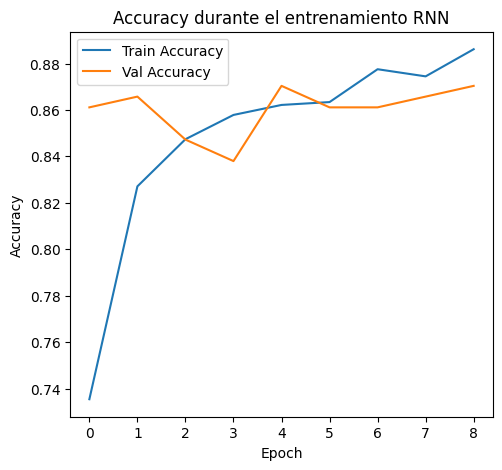

In [64]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento RNN')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.savefig(f"{dir_artifacts}/accuracy_epoch_rnn.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"accuracy_epoch_rnn_validacion": wandb.Image(plt)})
    
plt.legend()

In [65]:
# guardar el modelo entrenado 
best_model.save(f"{dir_artifacts}/best_rnn_model.h5", save_format='h5')

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluación - Validation

In [66]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_valid_pred = best_model.predict(X_valid)
y_valid_pred = np.argmax(y_valid_pred, axis=1)

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "validation/precision": precision,
        "validation/recall": recall,
        "validation/f1_score": f1
    })

7/7 [==============================] - 0s 2ms/step
Accuracy: 0.8703703703703703
                  precision    recall  f1-score   support

           Early       1.00      1.00      1.00        15
Inminent failure       0.50      0.83      0.62         6
          Normal       0.90      0.83      0.87        90
         Suspect       0.86      0.89      0.87       105

        accuracy                           0.87       216
       macro avg       0.82      0.89      0.84       216
    weighted avg       0.88      0.87      0.87       216



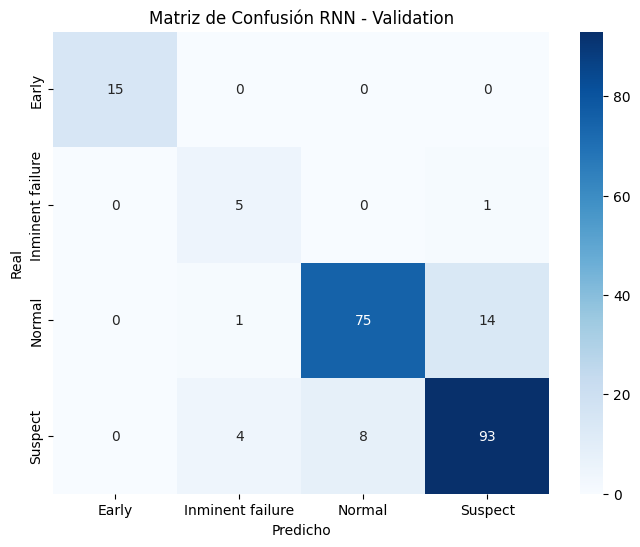

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión RNN - Validation")
plt.savefig(f"{dir_artifacts}/matriz_confusion_rnn_validation.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_rnn_validation": wandb.Image(plt)})

plt.show()

## Evaluación - Test

### 1st_test (subconjunto 10%)
Se empleo el subconjunto 10% del dataset empleado para el entrenamiento

In [68]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_test_pred = best_model.predict(X_test)
y_test_pred = np.argmax(y_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "test/precision": precision,
        "test/recall": recall,
        "test/f1_score": f1
    })

14/14 [==============================] - 0s 2ms/step
Accuracy: 0.8657407407407407
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       0.45      0.82      0.58        11
          Normal       0.88      0.87      0.87       180
         Suspect       0.88      0.85      0.86       211

        accuracy                           0.87       432
       macro avg       0.79      0.88      0.83       432
    weighted avg       0.87      0.87      0.87       432



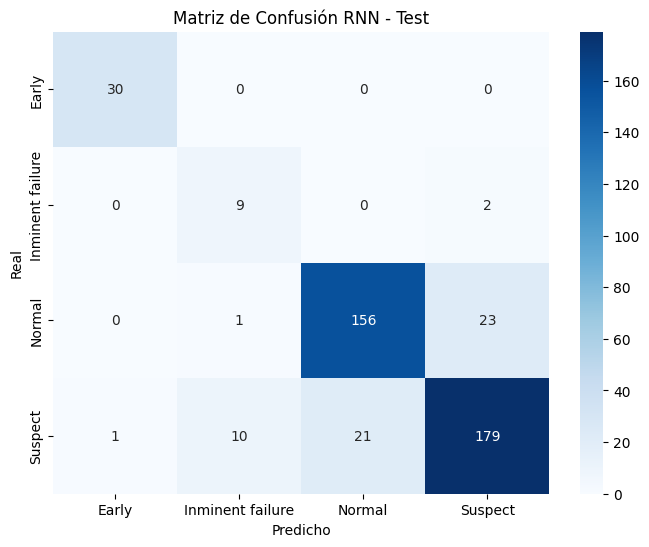

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión RNN - Test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_rnn_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_rnn_test": wandb.Image(plt)})

plt.show()

### 2_test
Se empleo el dataset 2nd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [70]:

y_2nd_test_pred = best_model.predict(X_2nd_test)
y_2nd_test_pred = np.argmax(y_2nd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_2nd_test, y_2nd_test_pred))

print(classification_report(
    y_2nd_test,
    y_2nd_test_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_2nd_test, y_2nd_test_pred, average='weighted')

    wandb.log({
        "2nd_test/precision": precision,
        "2nd_test/recall": recall,
        "2nd_test/f1_score": f1
    })

68/68 [==============================] - 0s 2ms/step
Accuracy: 0.885899814471243
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98       150
Inminent failure       0.59      0.95      0.73        56
          Normal       0.90      0.87      0.88       900
         Suspect       0.89      0.88      0.89      1050

        accuracy                           0.89      2156
       macro avg       0.84      0.92      0.87      2156
    weighted avg       0.89      0.89      0.89      2156



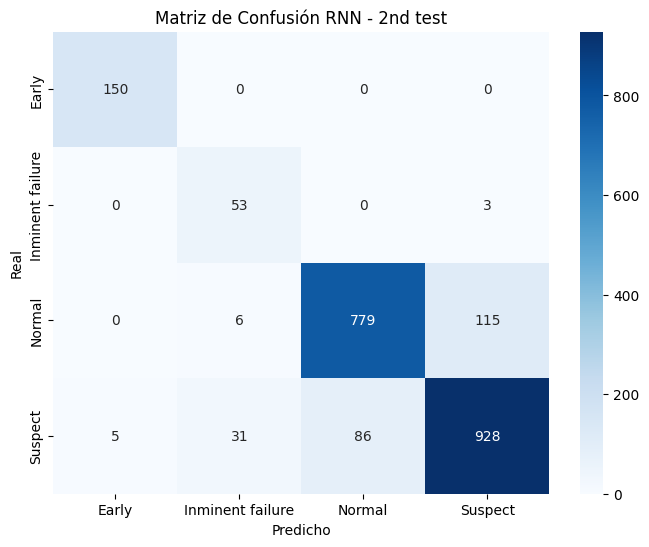

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_2nd_test, y_2nd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión RNN - 2nd test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_rnn_2nd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_rnn_2nd_test": wandb.Image(plt)})

plt.show()

### 3rd_test
Se empleo el dataset 3rd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [72]:

y_3rd_test_pred = best_model.predict(X_3rd_test)
y_3rd_test_pred = np.argmax(y_3rd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_3rd_test, y_3rd_test_pred))

print(classification_report(
    y_3rd_test,
    y_3rd_test_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_3rd_test, y_3rd_test_pred, average='weighted')

    wandb.log({
        "3rd_test/precision": precision,
        "3rd_test/recall": recall,
        "3rd_test/f1_score": f1
    })

198/198 [==============================] - 0s 2ms/step
Accuracy: 0.4519291587602783
                  precision    recall  f1-score   support

           Early       0.00      0.00      0.00         0
Inminent failure       0.26      0.73      0.39       395
          Normal       0.99      0.43      0.60      5929
         Suspect       0.00      0.00      0.00         0

        accuracy                           0.45      6324
       macro avg       0.31      0.29      0.25      6324
    weighted avg       0.95      0.45      0.59      6324



/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples

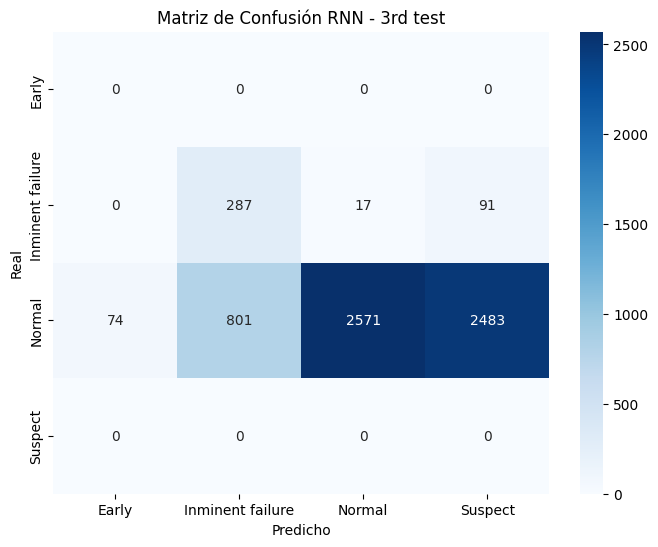

In [73]:
cm = confusion_matrix(y_3rd_test, y_3rd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión RNN - 3rd test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_rnn_3rd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_rnn_3rd_test": wandb.Image(plt)})

plt.show()

In [74]:
# Finalizar la ejecución
if usar_wandb:
    run.finish()

2nd_test/f1_score,▁
2nd_test/precision,▁
2nd_test/recall,▁
3rd_test/f1_score,▁
3rd_test/precision,▁
3rd_test/recall,▁
epoch/accuracy,▁▅▆▇▇▇█▇█
epoch/epoch,▁▂▃▄▅▅▆▇█
epoch/f1_score,▁▅▆▇▇▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁
+10,...


# LSTM

In [75]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def make_build_model(X_train, num_classes):
    def build_model(hp):
        model = Sequential([

            LSTM(
                units=hp.Int('lstm_units_1', min_value=32, max_value=256, step=32),
                return_sequences=True,
                input_shape=(X_train.shape[1], X_train.shape[2])
            ),

            Dropout(
                rate=hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)
            ),

            LSTM(
                units=hp.Int('lstm_units_2', min_value=16, max_value=128, step=16)
            ),

            Dense(
                units=hp.Int('dense_units', min_value=32, max_value=256, step=32),
                activation="relu"
            ),

            Dense(num_classes, activation="softmax")
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
            ),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy",
                # tf.keras.metrics.Precision(name='precision'),
                # tf.keras.metrics.Recall(name='recall'),
                F1MacroScore(num_classes=num_classes)]
        )

        return model
    return build_model

eval_metric = "val_f1_score"  
tuner = kt.Hyperband(
    make_build_model(X_train, num_classes),
    objective=kt.Objective(eval_metric, direction='max'),
    max_epochs=40,
    factor=3,
    directory='kt_results',
    project_name='lstm_vibraciones'
)

stop_early_monitor = 'val_loss'  
stop_early = tf.keras.callbacks.EarlyStopping(monitor=stop_early_monitor, patience=5)

# Búsqueda de hiperparámetros
tuner.search(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early]
)

tuner.results_summary()

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  lstm_units_1: {best_hps.get('lstm_units_1')}
  lstm_units_2: {best_hps.get('lstm_units_2')}
  dropout:      {best_hps.get('dropout_1')}
  dense_units:  {best_hps.get('dense_units')}
  lr:           {best_hps.get('lr')}
""")

if usar_wandb:
    config_params = {f"param_{k}": v for k, v in best_hps.values.items()}
    config_params["param_metrica_evaluacion"] = eval_metric
    config_params["param_stop_early_monitor"] = stop_early_monitor


Reloading Tuner from kt_results/lstm_vibraciones/tuner0.json
Results summary
Results in kt_results/lstm_vibraciones
Showing 10 best trials
Objective(name="val_f1_score", direction="max")

Trial 0086 summary
Hyperparameters:
lstm_units_1: 32
dropout_1: 0.4
lstm_units_2: 80
dense_units: 128
lr: 0.008326380697068002
tuner/epochs: 40
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.957563042640686

Trial 0083 summary
Hyperparameters:
lstm_units_1: 128
dropout_1: 0.1
lstm_units_2: 128
dense_units: 224
lr: 0.0005167397035568562
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0074
Score: 0.9575486779212952

Trial 0084 summary
Hyperparameters:
lstm_units_1: 224
dropout_1: 0.5
lstm_units_2: 16
dense_units: 160
lr: 0.003687492934224323
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0076
Score: 0.9575390219688416

Trial 0082 summary
Hyperparameters:
lstm_units_1: 128
dropout_1: 0.1
lstm_units_2: 128


In [76]:
if usar_wandb:
    # Iniciar run de wandb
    timestap_str = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M")
    run = wandb.init(
        entity="maanmuri-marck",
        project="TF_CEIA_Clasificador_Vibraciones",
        name=f"LSTM_agregados_v6_{timestap_str}",
        tags=["lstm", "hyperparameter_tuning", "precision_macro"],
        config={**config_params, **config_params_dataset}
    )
    run.log_artifact(dataset_artifact)

In [77]:
# Entrenar el modelo final con los mejores hiperparámetros
callbacks_list = [stop_early]

if usar_wandb:
    callbacks_list.append(WandbMetricsLogger())
    callbacks_list.append(WandbModelCheckpoint(
    filepath=f"{dir_artifacts}/best_lstm_model.keras", 
    monitor=stop_early_monitor, 
    save_best_only=True,
    load_weights_on_restart=True
))

best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    # validation_split=0.2,
    validation_data=(X_valid, y_valid),
    callbacks=callbacks_list
)

Epoch 1/40
204/204 [==============================] - 5s 10ms/step - loss: 0.6490 - accuracy: 0.7003 - f1_score: 0.7313 - val_loss: 0.4455 - val_accuracy: 0.8056 - val_f1_score: 0.8378
Epoch 2/40
204/204 [==============================] - 1s 7ms/step - loss: 0.4473 - accuracy: 0.8123 - f1_score: 0.8364 - val_loss: 0.3695 - val_accuracy: 0.8565 - val_f1_score: 0.8735
Epoch 3/40
204/204 [==============================] - 1s 7ms/step - loss: 0.3944 - accuracy: 0.8412 - f1_score: 0.8634 - val_loss: 0.4339 - val_accuracy: 0.8102 - val_f1_score: 0.8169
Epoch 4/40
204/204 [==============================] - 1s 7ms/step - loss: 0.3412 - accuracy: 0.8591 - f1_score: 0.8865 - val_loss: 0.3472 - val_accuracy: 0.8565 - val_f1_score: 0.8733
Epoch 5/40
204/204 [==============================] - 2s 7ms/step - loss: 0.3308 - accuracy: 0.8677 - f1_score: 0.8876 - val_loss: 0.3397 - val_accuracy: 0.8241 - val_f1_score: 0.8358
Epoch 6/40
204/204 [==============================] - 1s 7ms/step - loss: 0.320

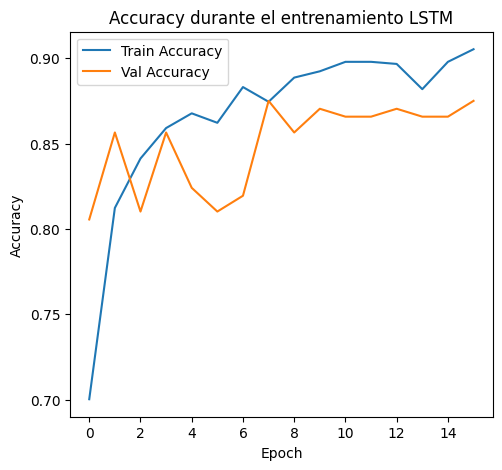

In [78]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento LSTM')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.savefig(f"{dir_artifacts}/accuracy_epoch_lstm.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"accuracy_epoch_lstm_validacion": wandb.Image(plt)})
    
plt.legend()

In [79]:
# guardar el modelo entrenado 
best_model.save(f"{dir_artifacts}/best_lstm_model.h5", save_format='h5')

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluación - Validation

In [80]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_valid_pred = best_model.predict(X_valid)
y_valid_pred = np.argmax(y_valid_pred, axis=1)

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "validation/precision": precision,
        "validation/recall": recall,
        "validation/f1_score": f1
    })

7/7 [==============================] - 1s 3ms/step
Accuracy: 0.875
                  precision    recall  f1-score   support

           Early       1.00      1.00      1.00        15
Inminent failure       0.83      0.83      0.83         6
          Normal       0.84      0.89      0.86        90
         Suspect       0.89      0.85      0.87       105

        accuracy                           0.88       216
       macro avg       0.89      0.89      0.89       216
    weighted avg       0.88      0.88      0.88       216



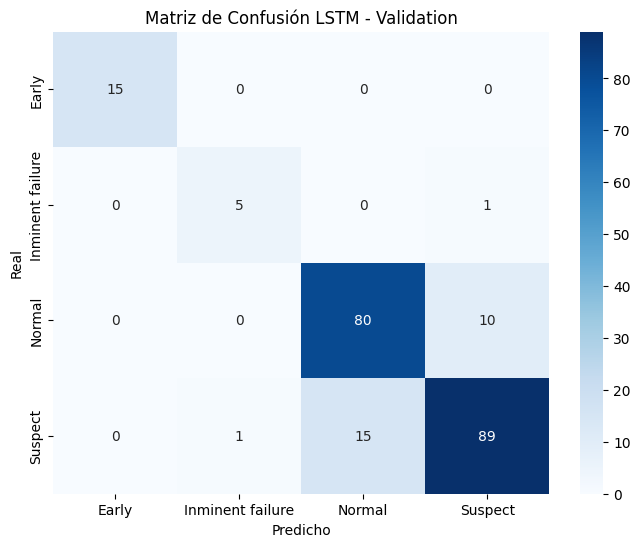

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión LSTM - Validation")
plt.savefig(f"{dir_artifacts}/matriz_confusion_lstm_validation.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_lstm_validation": wandb.Image(plt)})
    
plt.show()

## Evaluación - Test

### 1st_test (subconjunto 10%)
Se empleo el subconjunto 10% del dataset empleado para el entrenamiento

In [82]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_test_pred = best_model.predict(X_test)
y_test_pred = np.argmax(y_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "test/precision": precision,
        "test/recall": recall,
        "test/f1_score": f1
    })

14/14 [==============================] - 0s 3ms/step
Accuracy: 0.8657407407407407
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       0.64      0.82      0.72        11
          Normal       0.82      0.92      0.87       180
         Suspect       0.91      0.81      0.85       211

        accuracy                           0.87       432
       macro avg       0.84      0.89      0.86       432
    weighted avg       0.87      0.87      0.87       432



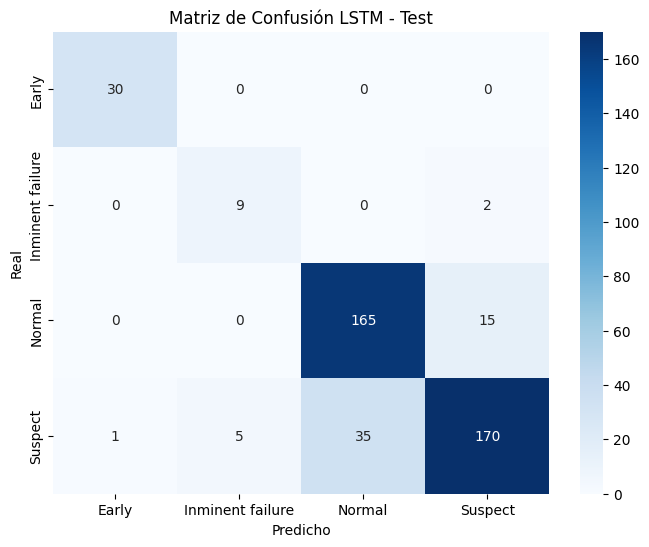

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión LSTM - Test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_lstm_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_lstm_test": wandb.Image(plt)})
    
plt.show()

### 2_test
Se empleo el dataset 2nd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [84]:
y_2nd_test_pred = best_model.predict(X_2nd_test)
y_2nd_test_pred = np.argmax(y_2nd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_2nd_test, y_2nd_test_pred))

print(classification_report(
    y_2nd_test,
    y_2nd_test_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_2nd_test, y_2nd_test_pred, average='weighted')

    wandb.log({
        "2nd_test/precision": precision,
        "2nd_test/recall": recall,
        "2nd_test/f1_score": f1
    })

68/68 [==============================] - 0s 3ms/step
Accuracy: 0.9095547309833024
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98       150
Inminent failure       0.85      0.95      0.90        56
          Normal       0.86      0.96      0.91       900
         Suspect       0.96      0.85      0.90      1050

        accuracy                           0.91      2156
       macro avg       0.91      0.94      0.92      2156
    weighted avg       0.91      0.91      0.91      2156



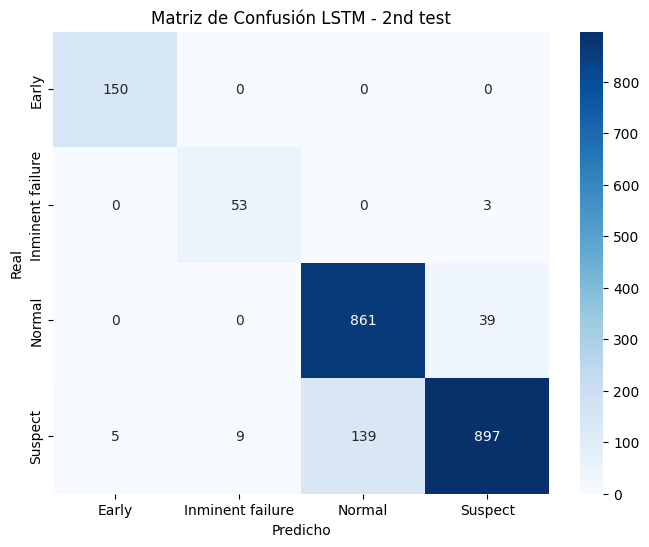

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_2nd_test, y_2nd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión LSTM - 2nd test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_lstm_2nd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_lstm_2nd_test": wandb.Image(plt)})
    
plt.show()

### 3rd_test
Se empleo el dataset 3rd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [86]:
y_3rd_test_pred = best_model.predict(X_3rd_test)
y_3rd_test_pred = np.argmax(y_3rd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_3rd_test, y_3rd_test_pred))

print(classification_report(
    y_3rd_test,
    y_3rd_test_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_3rd_test, y_3rd_test_pred, average='weighted')

    wandb.log({
        "3rd_test/precision": precision,
        "3rd_test/recall": recall,
        "3rd_test/f1_score": f1
    })

198/198 [==============================] - 1s 3ms/step
Accuracy: 0.7321315623023403
                  precision    recall  f1-score   support

           Early       0.00      0.00      0.00         0
Inminent failure       0.23      0.57      0.32       395
          Normal       0.99      0.74      0.85      5929
         Suspect       0.00      0.00      0.00         0

        accuracy                           0.73      6324
       macro avg       0.30      0.33      0.29      6324
    weighted avg       0.94      0.73      0.81      6324



/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples

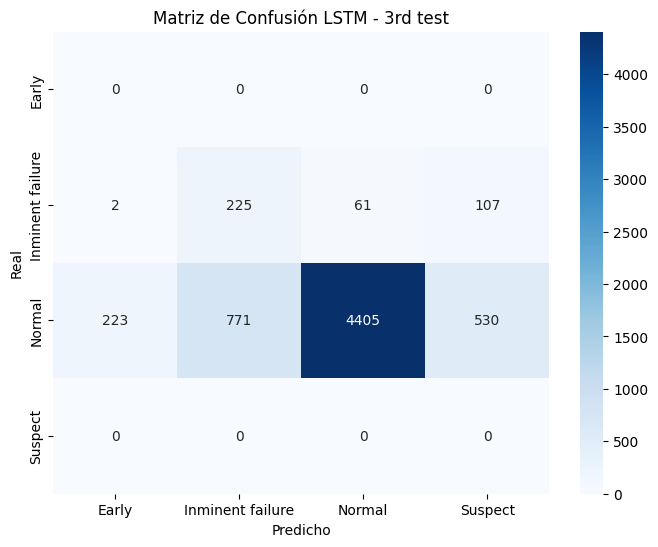

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_3rd_test, y_3rd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión LSTM - 3rd test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_lstm_3rd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_lstm_3rd_test": wandb.Image(plt)})
    
plt.show()

In [88]:
# Finalizar la ejecución
if usar_wandb:
    run.finish()

2nd_test/f1_score,▁
2nd_test/precision,▁
2nd_test/recall,▁
3rd_test/f1_score,▁
3rd_test/precision,▁
3rd_test/recall,▁
epoch/accuracy,▁▅▆▆▇▇▇▇▇████▇██
epoch/epoch,▁▁▂▂▃▃▄▄▅▅▆▆▇▇██
epoch/f1_score,▁▅▆▇▇▇▇▇▇▇███▇██
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+10,...


# Deep Neural Network

In [89]:
# Dado que este modelo espera una entrada 2D, necesitamos aplanar cada muestra de 8xfeatures a un vector de features. Esto se hace con reshape, manteniendo el número de muestras (X_train.shape[0]) y aplanando el resto (-1).
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d  = X_test.reshape(X_test.shape[0], -1)
X_valid_2d   = X_valid.reshape(X_valid.shape[0], -1)

print(X_train_2d.shape)  # (1724, 168)
print(X_test_2d.shape)   # (431, 168)
print(X_valid_2d.shape) # (216, 168)

(1625, 40)
(432, 40)
(216, 40)


In [90]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def make_build_model(X_train, num_classes):
    num_features = X_train.shape[1] * X_train.shape[2]

    def build_model(hp):
        model = Sequential([

            Dense(
                units=hp.Int('dense_units_1', min_value=64, max_value=256, step=32),
                activation="relu",
                input_shape=(num_features,)
            ),

            Dense(
                units=hp.Int('dense_units_2', min_value=32, max_value=128, step=32),
                activation="relu"
            ),

            Dense(
                units=hp.Int('dense_units_3', min_value=16, max_value=64, step=16),
                activation="relu"
            ),

            Dropout(
                rate=hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)
            ),

            Dense(num_classes, activation="softmax")
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
            ),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy",
                # tf.keras.metrics.Precision(name='precision'),
                # tf.keras.metrics.Recall(name='recall'),
                F1MacroScore(num_classes=num_classes)]
        )

        return model
    return build_model


eval_metric = "val_f1_score" 
tuner = kt.Hyperband(
    make_build_model(X_train, num_classes),
    objective=kt.Objective(eval_metric, direction='max'),
    max_epochs=40,
    factor=3,
    directory='kt_results',
    project_name='mlp_vibraciones'
)

stop_early_monitor = 'val_loss'  
stop_early = tf.keras.callbacks.EarlyStopping(monitor=stop_early_monitor, patience=5)

# aplanar X a 2D antes de entrenar
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_val_2d   = X_valid.reshape(X_valid.shape[0], -1)

tuner.search(
    X_train_2d,
    y_train,
    epochs=40,
    batch_size=8,
    validation_data=(X_val_2d, y_valid),
    callbacks=[stop_early]
)

tuner.results_summary()

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  dense_units_1: {best_hps.get('dense_units_1')}
  dense_units_2: {best_hps.get('dense_units_2')}
  dense_units_3: {best_hps.get('dense_units_3')}
  dropout:       {best_hps.get('dropout')}
  lr:            {best_hps.get('lr')}
""")

if usar_wandb:
    config_params = {f"param_{k}": v for k, v in best_hps.values.items()}
    config_params["param_metrica_evaluacion"] = eval_metric
    config_params["param_stop_early_monitor"] = stop_early_monitor

Reloading Tuner from kt_results/mlp_vibraciones/tuner0.json
Results summary
Results in kt_results/mlp_vibraciones
Showing 10 best trials
Objective(name="val_f1_score", direction="max")

Trial 0077 summary
Hyperparameters:
dense_units_1: 96
dense_units_2: 64
dense_units_3: 32
dropout: 0.5
lr: 0.0014825733072079664
tuner/epochs: 14
tuner/initial_epoch: 0
tuner/bracket: 1
tuner/round: 0
Score: 0.979971170425415

Trial 0087 summary
Hyperparameters:
dense_units_1: 128
dense_units_2: 64
dense_units_3: 64
dropout: 0.5
lr: 0.0038539501398167143
tuner/epochs: 40
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.979971170425415

Trial 0078 summary
Hyperparameters:
dense_units_1: 192
dense_units_2: 32
dense_units_3: 32
dropout: 0.1
lr: 0.0002401891792157938
tuner/epochs: 14
tuner/initial_epoch: 0
tuner/bracket: 1
tuner/round: 0
Score: 0.9786841869354248

Trial 0050 summary
Hyperparameters:
dense_units_1: 64
dense_units_2: 32
dense_units_3: 64
dropout: 0.30000000000000004
lr: 0.00199

In [91]:
if usar_wandb:
    # Iniciar run de wandb
    timestap_str = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M")
    run = wandb.init(
        entity="maanmuri-marck",
        project="TF_CEIA_Clasificador_Vibraciones",
        name=f"DNN_agregados_v6_{timestap_str}",
        tags=["dnn", "hyperparameter_tuning", "precision_macro"],
        config={**config_params, **config_params_dataset}
    )
    run.log_artifact(dataset_artifact)

In [92]:
# Entrenar el modelo final con los mejores hiperparámetros
callbacks_list = [stop_early]

if usar_wandb:
    callbacks_list.append(WandbMetricsLogger())
    callbacks_list.append(WandbModelCheckpoint(
    filepath=f"{dir_artifacts}/best_dnn_model.keras", 
    monitor=stop_early_monitor, 
    save_best_only=True,
    load_weights_on_restart=True
))

best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train_2d,
    y_train,
    epochs=40,
    batch_size=8,
    validation_data=(X_val_2d, y_valid),
    callbacks=callbacks_list
)

Epoch 1/40
204/204 [==============================] - 1s 3ms/step - loss: 0.7852 - accuracy: 0.6886 - f1_score: 0.6732 - val_loss: 0.4351 - val_accuracy: 0.8333 - val_f1_score: 0.8428
Epoch 2/40
204/204 [==============================] - 1s 3ms/step - loss: 0.4772 - accuracy: 0.8271 - f1_score: 0.8348 - val_loss: 0.4084 - val_accuracy: 0.8611 - val_f1_score: 0.8446
Epoch 3/40
204/204 [==============================] - 1s 3ms/step - loss: 0.3993 - accuracy: 0.8480 - f1_score: 0.8650 - val_loss: 0.4079 - val_accuracy: 0.8657 - val_f1_score: 0.8461
Epoch 4/40
204/204 [==============================] - 1s 3ms/step - loss: 0.3632 - accuracy: 0.8634 - f1_score: 0.8749 - val_loss: 0.3941 - val_accuracy: 0.8380 - val_f1_score: 0.8320
Epoch 5/40
204/204 [==============================] - 1s 3ms/step - loss: 0.3254 - accuracy: 0.8769 - f1_score: 0.8943 - val_loss: 0.3861 - val_accuracy: 0.8796 - val_f1_score: 0.8860
Epoch 6/40
204/204 [==============================] - 1s 3ms/step - loss: 0.3216

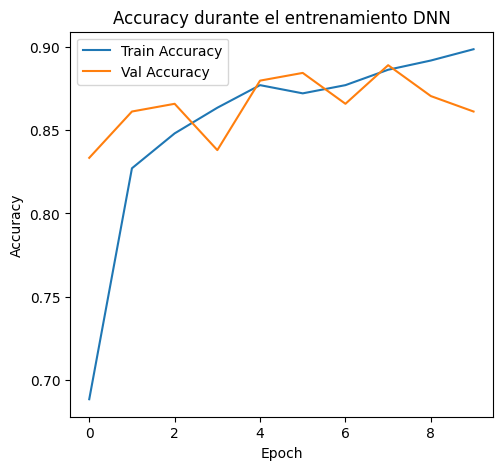

In [93]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento DNN')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.savefig(f"{dir_artifacts}/accuracy_epoch_dnn.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"accuracy_epoch_dnn_validacion": wandb.Image(plt)})
    
plt.legend()

In [94]:
# guardar el modelo entrenado 
best_model.save(f"{dir_artifacts}/best_dnn_model.h5")

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluación - Validation

In [95]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

y_valid_pred = best_model.predict(X_valid_2d)
y_valid_pred = np.argmax(y_valid_pred, axis=1)

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "validation/precision": precision,
        "validation/recall": recall,
        "validation/f1_score": f1
    })

7/7 [==============================] - 0s 4ms/step
Accuracy: 0.8611111111111112
                  precision    recall  f1-score   support

           Early       1.00      1.00      1.00        15
Inminent failure       0.50      0.83      0.62         6
          Normal       0.92      0.79      0.85        90
         Suspect       0.83      0.90      0.87       105

        accuracy                           0.86       216
       macro avg       0.81      0.88      0.84       216
    weighted avg       0.87      0.86      0.86       216



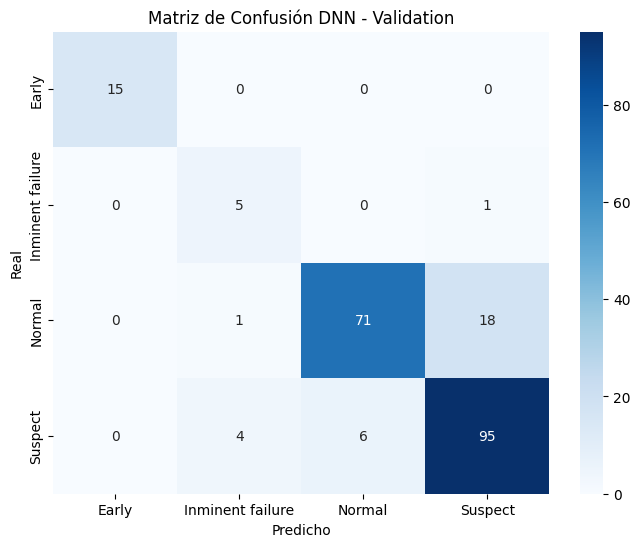

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión DNN - Validation")
plt.savefig(f"{dir_artifacts}/matriz_confusion_dnn_validation.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_dnn_validation": wandb.Image(plt)})
    
plt.show()

## Evaluación - Test

### 1st_test (subconjunto 10%)
Se empleo el subconjunto 10% del dataset empleado para el entrenamiento

In [97]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

y_test_pred = best_model.predict(X_test_2d)
y_test_pred = np.argmax(y_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "test/precision": precision,
        "test/recall": recall,
        "test/f1_score": f1
    })

14/14 [==============================] - 0s 1ms/step
Accuracy: 0.8472222222222222
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       0.56      0.82      0.67        11
          Normal       0.88      0.80      0.84       180
         Suspect       0.83      0.87      0.85       211

        accuracy                           0.85       432
       macro avg       0.81      0.87      0.83       432
    weighted avg       0.85      0.85      0.85       432



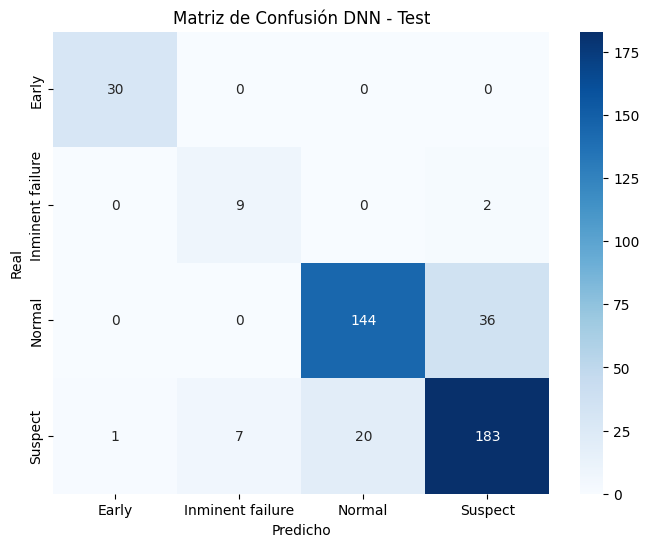

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión DNN - Test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_dnn_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_dnn_test": wandb.Image(plt)})
    
plt.show()

### 2_test
Se empleo el dataset 2nd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [99]:
y_2nd_test_pred = best_model.predict(X_2nd_test_2d)
y_2nd_test_pred = np.argmax(y_2nd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_2nd_test, y_2nd_test_pred))

print(classification_report(
    y_2nd_test,
    y_2nd_test_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_2nd_test, y_2nd_test_pred, average='weighted')

    wandb.log({
        "2nd_test/precision": precision,
        "2nd_test/recall": recall,
        "2nd_test/f1_score": f1
    })

68/68 [==============================] - 0s 995us/step
Accuracy: 0.8928571428571429
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98       150
Inminent failure       0.74      0.95      0.83        56
          Normal       0.92      0.85      0.88       900
         Suspect       0.88      0.91      0.89      1050

        accuracy                           0.89      2156
       macro avg       0.87      0.93      0.90      2156
    weighted avg       0.89      0.89      0.89      2156



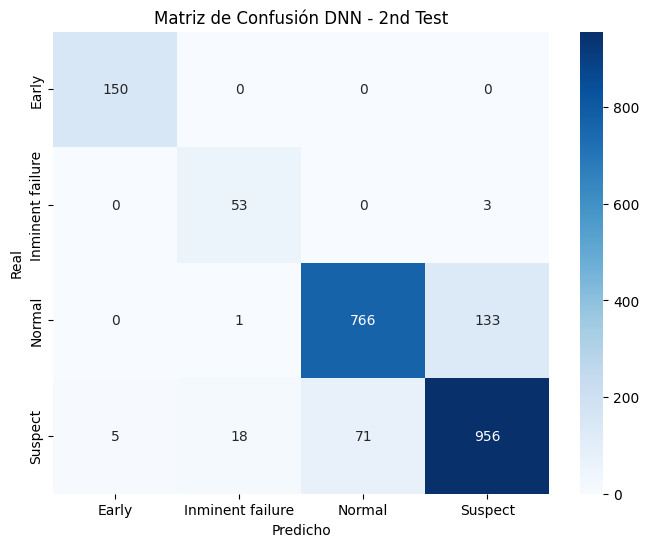

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_2nd_test, y_2nd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión DNN - 2nd Test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_dnn_2nd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_dnn_2nd_test": wandb.Image(plt)})
    
plt.show()

### 3rd_test
Se empleo el dataset 3rd_test del IMS con un etiquetado manual realizado en `TF_Generador_Datasets.ipynb`

In [101]:
y_3rd_test_pred = best_model.predict(X_3rd_test_2d)
y_3rd_test_pred = np.argmax(y_3rd_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_3rd_test, y_3rd_test_pred))

print(classification_report(
    y_3rd_test,
    y_3rd_test_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_3rd_test, y_3rd_test_pred, average='weighted')

    wandb.log({
        "3rd_test/precision": precision,
        "3rd_test/recall": recall,
        "3rd_test/f1_score": f1
    })

198/198 [==============================] - 0s 1ms/step
Accuracy: 0.31704617330803286
                  precision    recall  f1-score   support

           Early       0.00      0.00      0.00         0
Inminent failure       0.24      0.46      0.32       395
          Normal       0.99      0.31      0.47      5929
         Suspect       0.00      0.00      0.00         0

        accuracy                           0.32      6324
       macro avg       0.31      0.19      0.20      6324
    weighted avg       0.94      0.32      0.46      6324



/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples

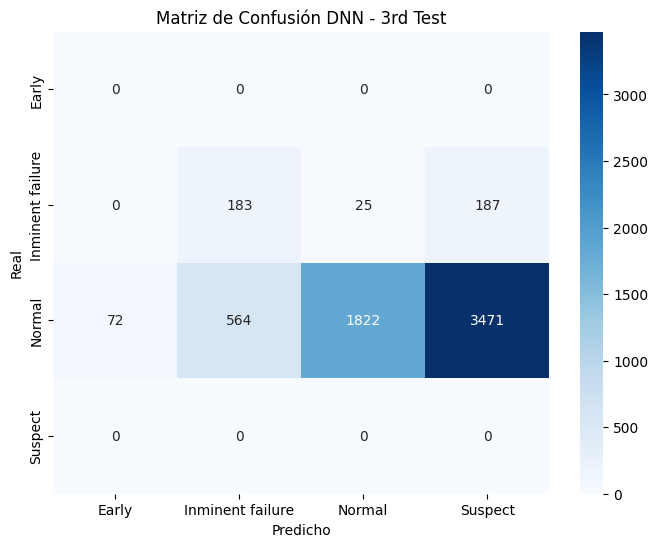

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_3rd_test, y_3rd_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión DNN - 3rd Test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_dnn_3rd_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_dnn_3rd_test": wandb.Image(plt)})
    
plt.show()

In [103]:
# Finalizar la ejecución
if usar_wandb:
    run.finish()

2nd_test/f1_score,▁
2nd_test/precision,▁
2nd_test/recall,▁
3rd_test/f1_score,▁
3rd_test/precision,▁
3rd_test/recall,▁
epoch/accuracy,▁▆▆▇▇▇▇███
epoch/epoch,▁▂▃▃▄▅▆▆▇█
epoch/f1_score,▁▆▆▇▇▇████
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁
+10,...
